# Predicting Irrigation Need

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.metrics import accuracy_score

pd.set_option('display.max_columns', None)

In [2]:
df_train = pd.read_csv("/content/drive/MyDrive/ML/Predicting Irrigation Need/dataset/train.csv")
df_test = pd.read_csv("/content/drive/MyDrive/ML/Predicting Irrigation Need/dataset/test.csv")

In [3]:
df_train.shape, df_test.shape

((630000, 21), (270000, 20))

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [5]:
df_train['Irrigation_Need'].value_counts()

,count
Irrigation_Need,
Low,369917
Medium,239074
High,21009


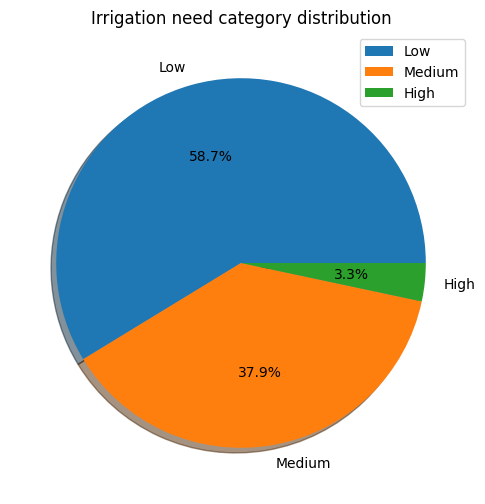

In [6]:
irr_need = df_train["Irrigation_Need"].value_counts(normalize=True) * 100
irr_need = irr_need.reset_index()
plt.figure(figsize=(14,6))

plt.pie(
    x=irr_need['proportion'],
    labels=irr_need['Irrigation_Need'],
    autopct='%1.1f%%',
    shadow=True
)

plt.legend()
plt.title("Irrigation need category distribution")
plt.show()

The target variable Irrigation_Need is imbalanced. The majority class is Low (~59%), followed by Medium (~38%), while High (~3%) is a rare minority class.

In [7]:
df_train.isnull().sum()

,0
id,0
Soil_Type,0
Soil_pH,0
Soil_Moisture,0
Organic_Carbon,0
Electrical_Conductivity,0
Temperature_C,0
Humidity,0
Rainfall_mm,0
Sunlight_Hours,0




> No missing values in training dataset



In [8]:
df_train.duplicated().sum()

np.int64(0)



> No duplicated values



In [9]:
df_train.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


No obvious invalid numerical ranges were found in the dataset. All environmental and agricultural attributes lie within realistic domain-specific limits. Features such as soil pH, humidity, temperature, rainfall, and irrigation measurements appear consistent and suitable for further preprocessing and modeling.

In [10]:
numeric_columns = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

outlier_percentage = {}

for column in numeric_columns:
  column_data = df_train[column]

  Q1 = np.quantile(column_data, 0.25)
  Q3 = np.quantile(column_data, 0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = column_data[(column_data < lower_bound) | (column_data > upper_bound)]
  outlier_percentage[column] = len(outliers) / len(column_data) * 100

  for column, percentage in outlier_percentage.items():
    print(f"Count of outliers in column: '{column}' : {len(outliers)}")
    print(f"Percentage of outliers in column '{column}':{percentage:.2f}%")
    print()
    print(f"Lower : {lower_bound}")
    print(f"Upper : {upper_bound}")

Count of outliers in column: 'id' : 0
Percentage of outliers in column 'id':0.00%

Lower : -314999.5
Upper : 944998.5
Count of outliers in column: 'id' : 0
Percentage of outliers in column 'id':0.00%

Lower : 3.3200000000000016
Upper : 9.639999999999999
Count of outliers in column: 'Soil_pH' : 0
Percentage of outliers in column 'Soil_pH':0.00%

Lower : 3.3200000000000016
Upper : 9.639999999999999
Count of outliers in column: 'id' : 0
Percentage of outliers in column 'id':0.00%

Lower : -18.555000000000003
Upper : 93.165
Count of outliers in column: 'Soil_pH' : 0
Percentage of outliers in column 'Soil_pH':0.00%

Lower : -18.555000000000003
Upper : 93.165
Count of outliers in column: 'Soil_Moisture' : 0
Percentage of outliers in column 'Soil_Moisture':0.00%

Lower : -18.555000000000003
Upper : 93.165
Count of outliers in column: 'id' : 0
Percentage of outliers in column 'id':0.00%

Lower : -0.30500000000000005
Upper : 2.135
Count of outliers in column: 'Soil_pH' : 0
Percentage of outlier

No significant outliers were detected in any numerical feature using the IQR method. All variables fall within acceptable lower and upper bounds, indicating that the dataset is clean and does not require outlier treatment before model training.

In [11]:
len(numeric_columns)

12

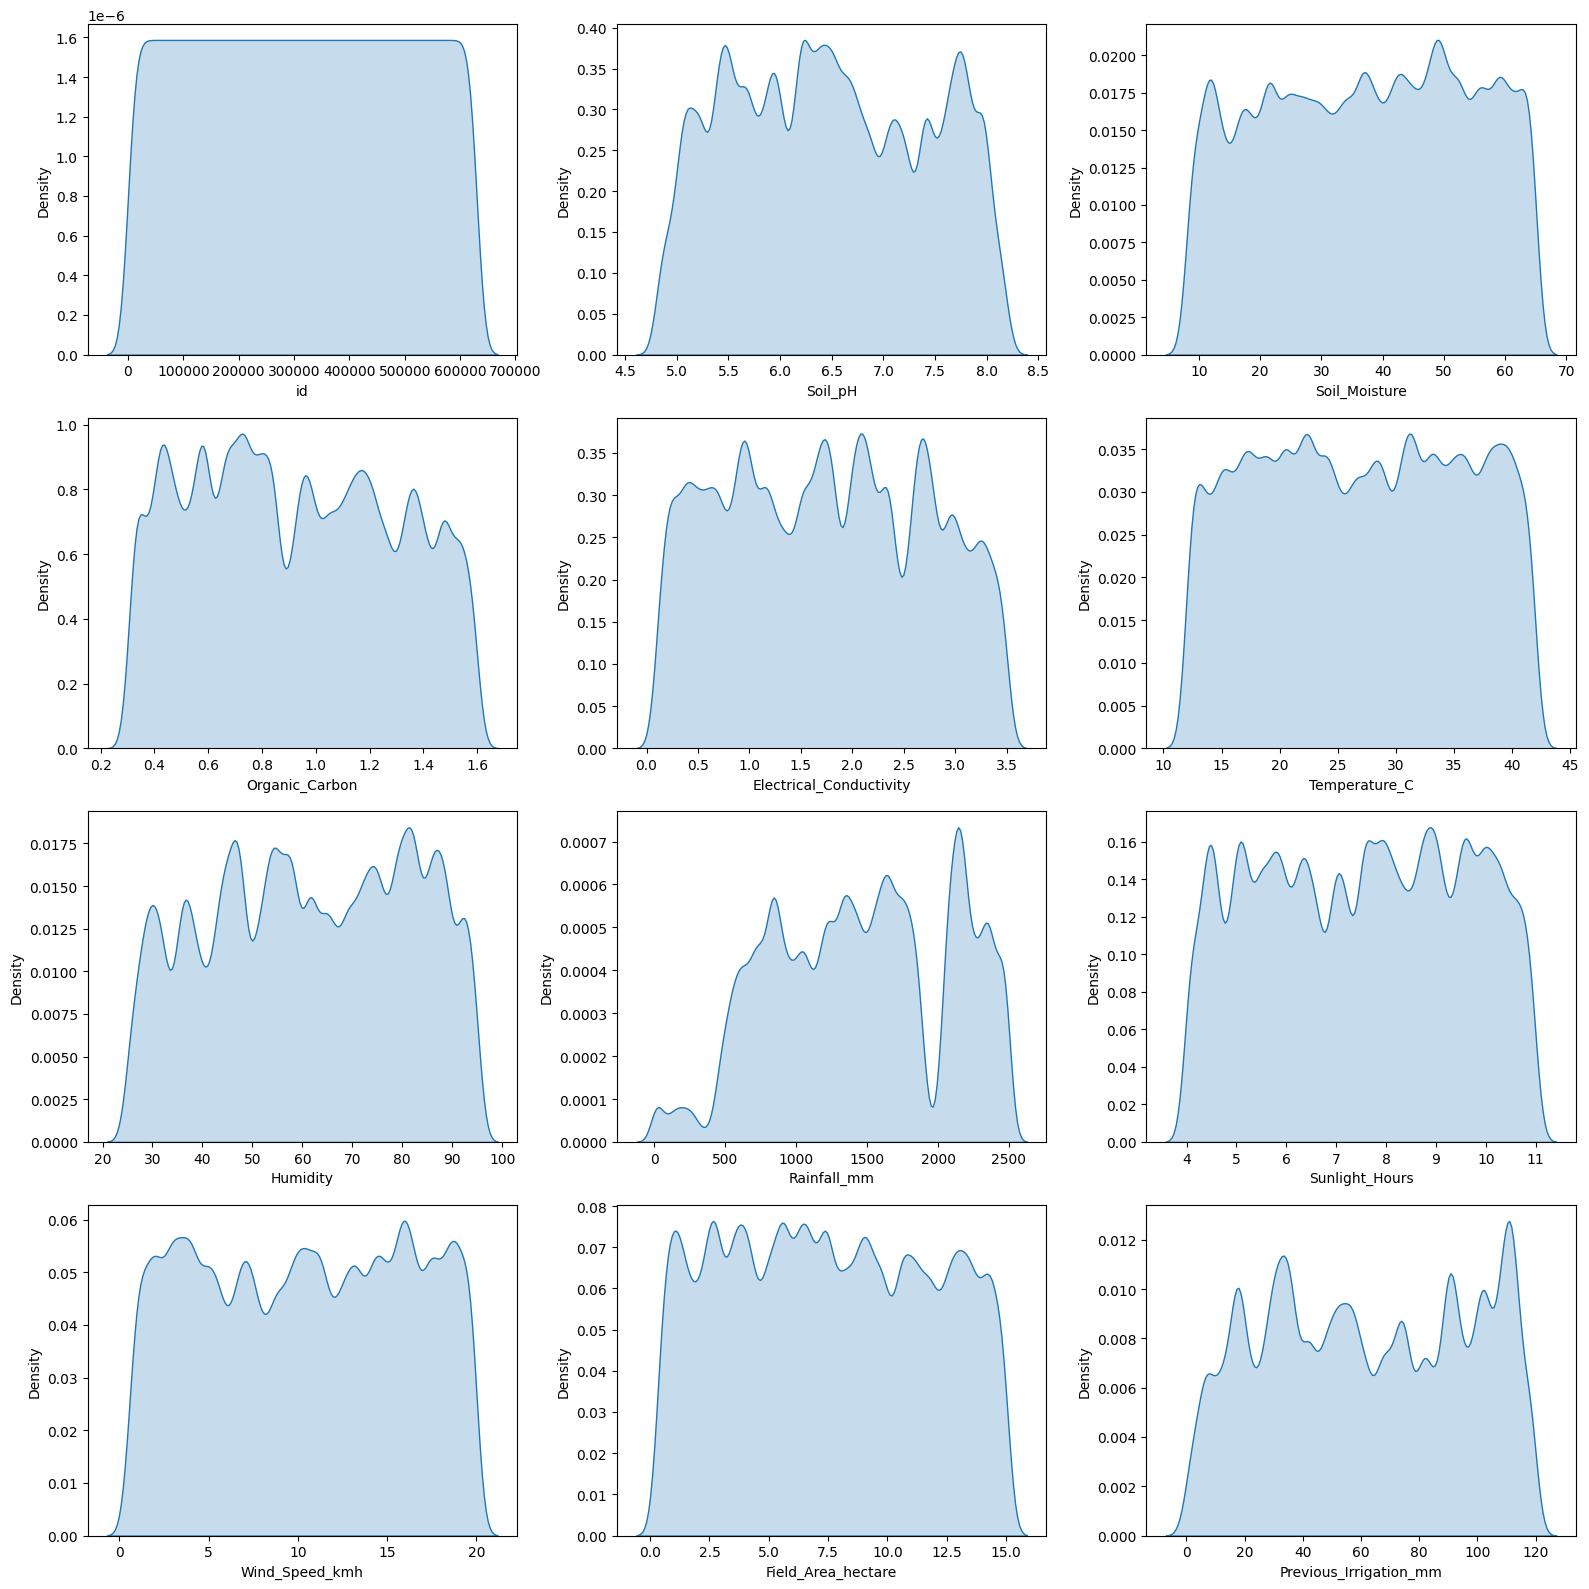

In [12]:
from collections.abc import ValuesView
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create the grid
fig, axes = plt.subplots(4, 3, figsize=(16, 16)) # Increased height for 4 rows

# 2. Flatten the axes array from 2D to 1D
axes = axes.flatten()

# 3. Plot using a single index (0 to 11)
for index, value in enumerate(numeric_columns):
  sns.kdeplot(
      data=df_train,
      x=value,
      ax=axes[index],
      fill=True
  )

# Optional: Hide any unused subplots at the end if you have fewer than 12 features
# for i in range(number_of_features, len(axes)):
#     fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Most numerical features are approximately uniformly distributed and show very low skewness. No major outliers are observed, and the variables do not follow a normal (Gaussian) distribution. The dataset appears clean, balanced in feature spread, and likely synthetically generated or extensively preprocessed.

In [13]:
df_train.sample(1)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
372758,372758,Silt,7.71,57.54,1.14,2.56,26.19,61.97,1408.3,4.11,4.37,Maize,Vegetative,Rabi,Drip,Rainwater,4.14,Yes,116.84,Central,Low


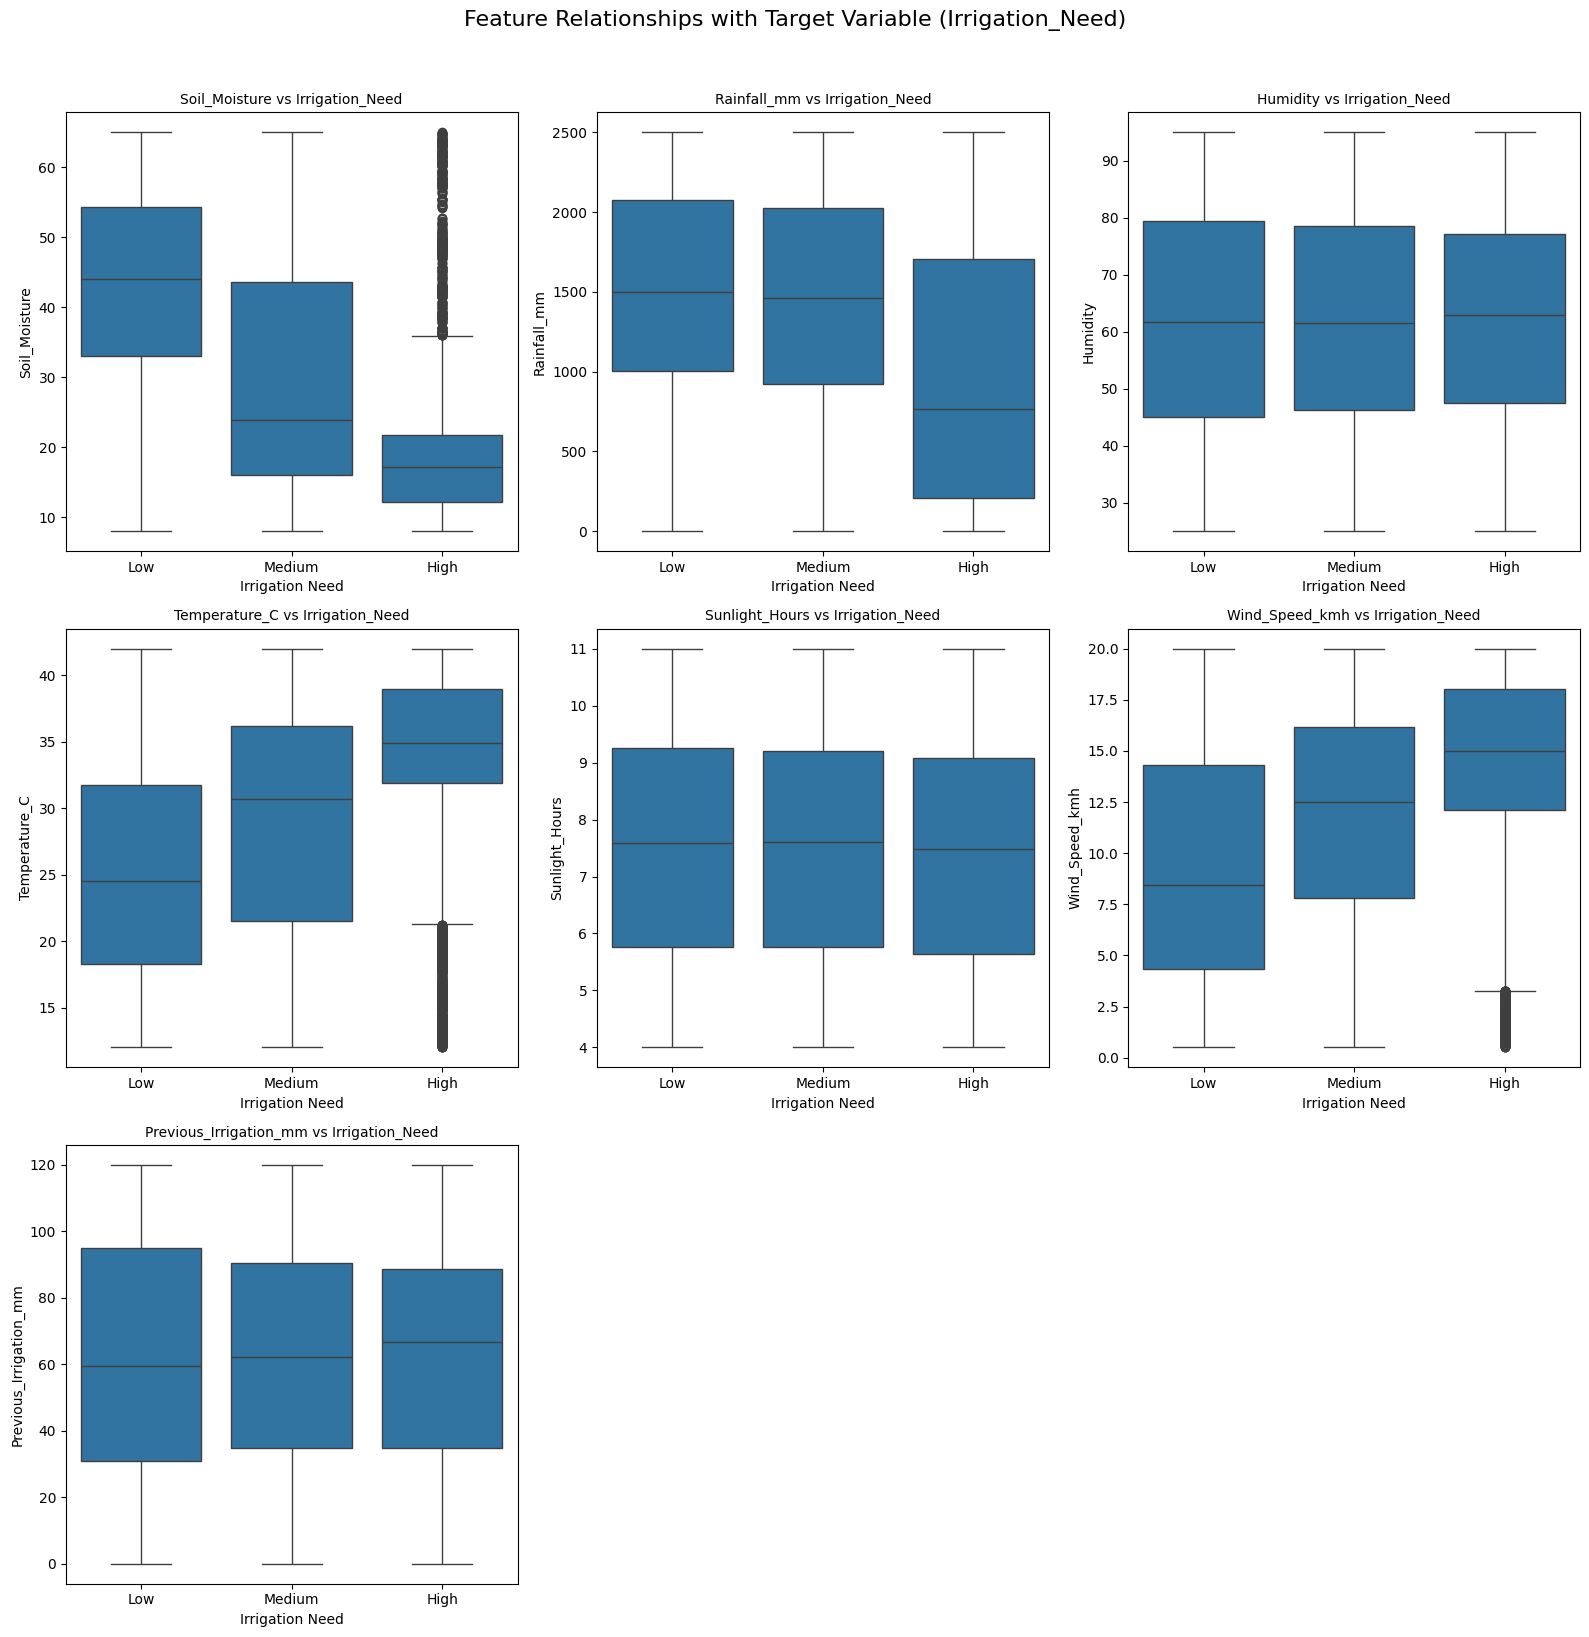

In [14]:
list = ['Soil_Moisture', 'Rainfall_mm', 'Humidity', 'Temperature_C', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Previous_Irrigation_mm']

fig, axes = plt.subplots(3, 3, figsize=(16, 16))
axes = axes.flatten()
for index, value in enumerate(list):
  sns.boxplot(
      data=df_train,
      x='Irrigation_Need',
      y=value,
      ax=axes[index]
  )
  axes[index].set_title(f"{value} vs Irrigation_Need", fontsize=10)
  axes[index].set_xlabel('Irrigation Need')
  axes[index].set_ylabel(value)

for i in range(len(list), len(axes)):
  fig.delaxes(axes[i])

plt.suptitle("Feature Relationships with Target Variable (Irrigation_Need)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

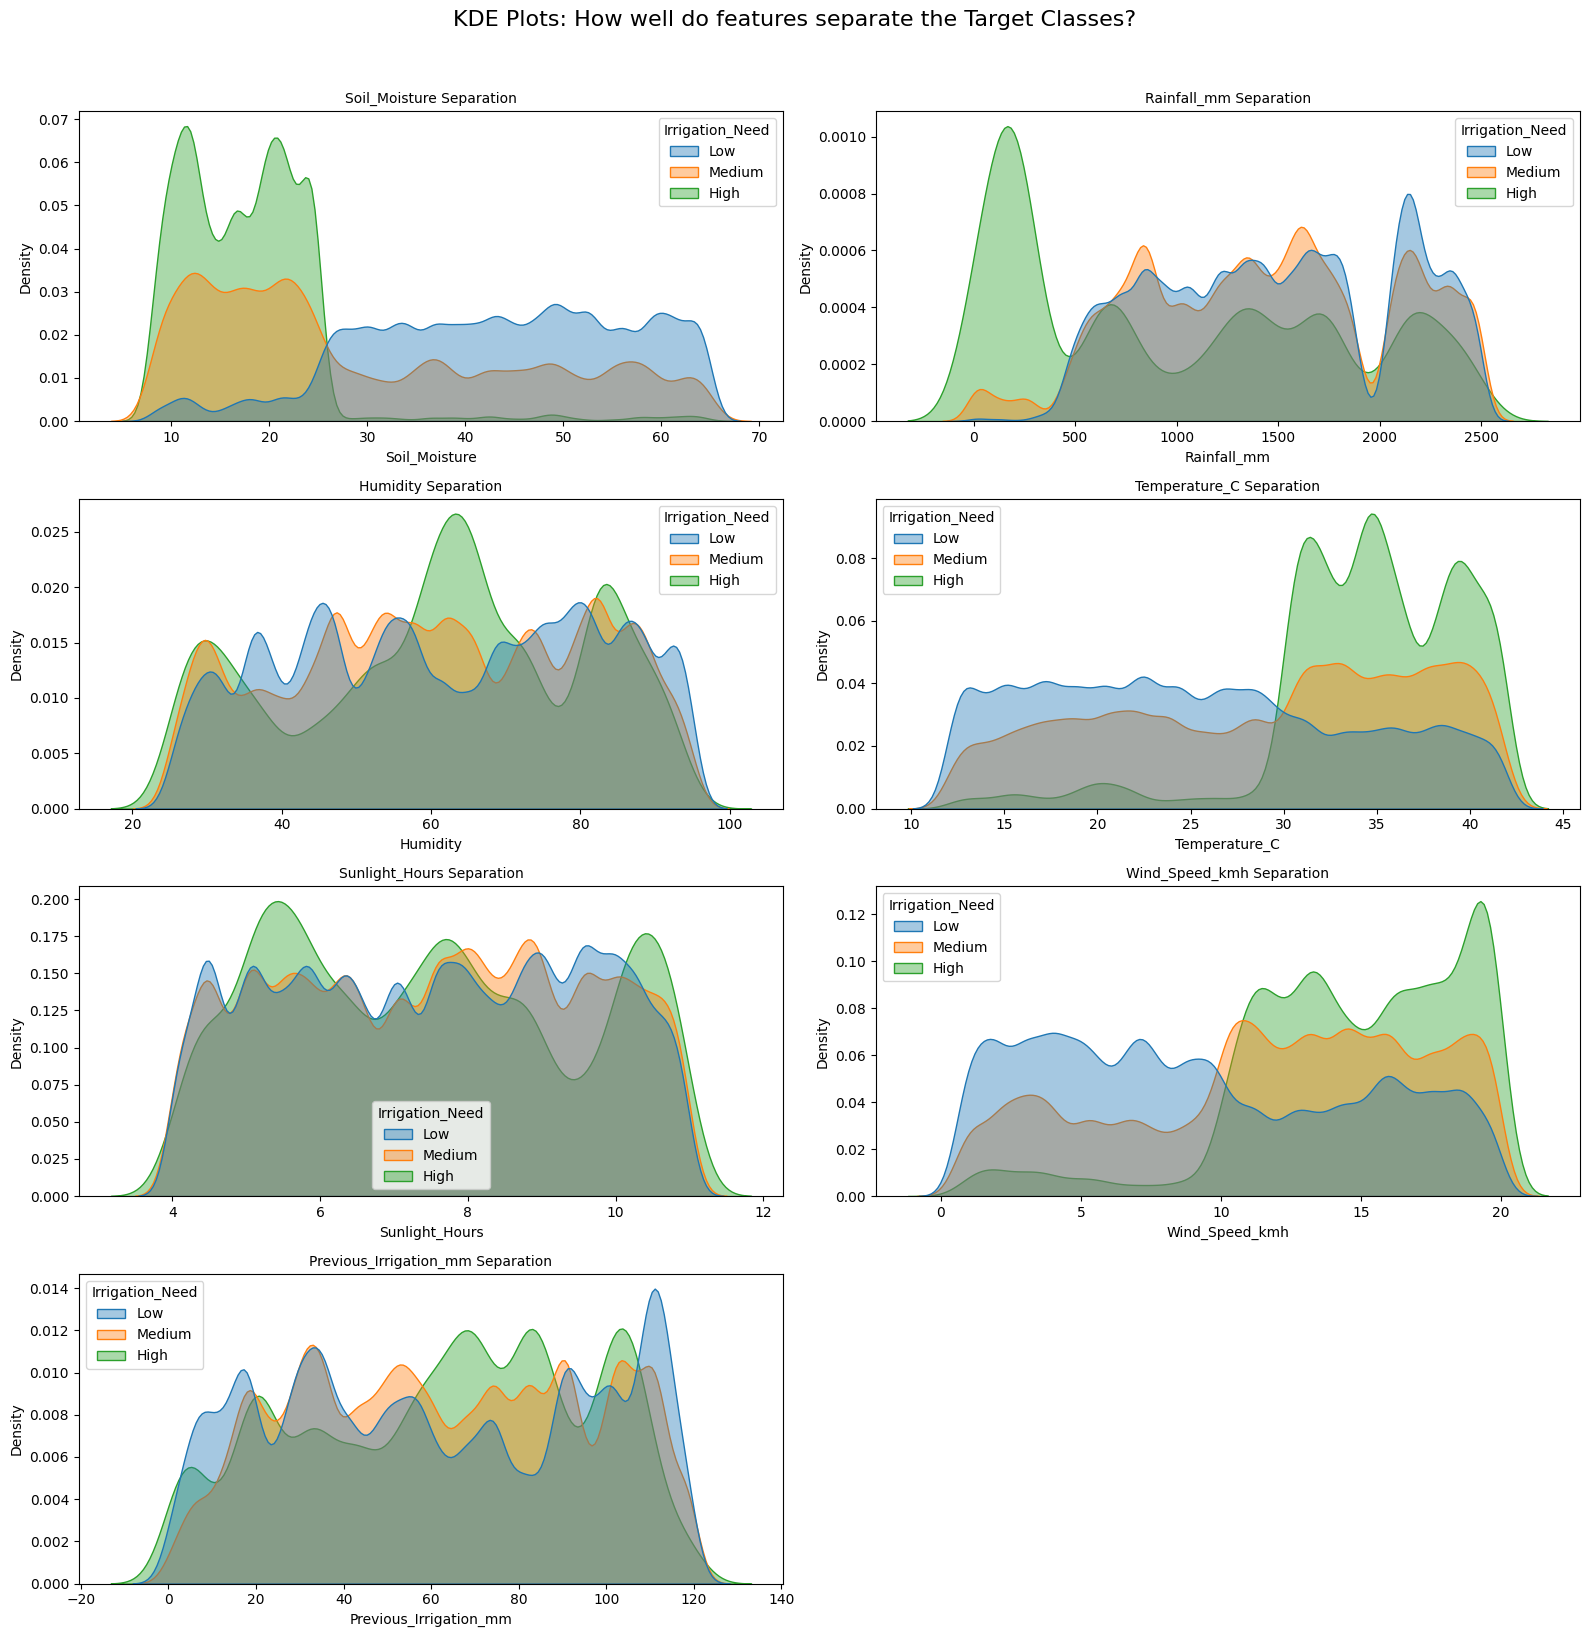

In [15]:
features = ['Soil_Moisture', 'Rainfall_mm', 'Humidity', 'Temperature_C', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Previous_Irrigation_mm']

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for index, value in enumerate(features):
    sns.kdeplot(
        data=df_train,
        x=value,
        hue='Irrigation_Need',
        ax=axes[index],
        fill=True,
        common_norm=False, # Normalizes each curve individually
        alpha=0.4
    )
    axes[index].set_title(f"{value} Separation", fontsize=10)

for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("KDE Plots: How well do features separate the Target Classes?", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Soil moisture, temperature, and rainfall are the most influential factors affecting irrigation need. Low soil moisture and low rainfall significantly increase irrigation demand, while high temperature further intensifies water requirements. Previous irrigation amount and sunlight hours show comparatively weaker relationships with the target variable.

# Feature Importance Ranking (Visual Interpretation)

## Based on class separation strength:

### Feature	Influence on Irrigation Need:

- Soil_Moisture	-> Very Strong
- Temperature_C	-> Strong
- Rainfall_mm	-> Strong
- Wind_Speed_kmh	-> Moderate
- Humidity	-> Weak-Moderate
- Previous_Irrigation_mm	-> Weak
- Sunlight_Hours	-> Weak

In [16]:
categorical_feature = df_train.select_dtypes(include=['object']).columns.tolist()

In [17]:
len(categorical_feature)

9

In [18]:
categorical_feature

['Soil_Type',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Season',
 'Irrigation_Type',
 'Water_Source',
 'Mulching_Used',
 'Region',
 'Irrigation_Need']

In [19]:
for i, v in enumerate(categorical_feature):
  print(f"{v} -> {df_train[v].unique()}")

Soil_Type -> ['Loamy' 'Clay' 'Sandy' 'Silt']
Crop_Type -> ['Sugarcane' 'Wheat' 'Rice' 'Potato' 'Cotton' 'Maize']
Crop_Growth_Stage -> ['Sowing' 'Vegetative' 'Flowering' 'Harvest']
Season -> ['Zaid' 'Kharif' 'Rabi']
Irrigation_Type -> ['Drip' 'Rainfed' 'Sprinkler' 'Canal']
Water_Source -> ['Rainwater' 'River' 'Reservoir' 'Groundwater']
Mulching_Used -> ['No' 'Yes']
Region -> ['East' 'South' 'North' 'West' 'Central']
Irrigation_Need -> ['Low' 'Medium' 'High']


In [20]:
crosstab = pd.crosstab(df_train['Soil_Type'], df_train['Irrigation_Need'], normalize='index') * 100

In [21]:
crosstab = crosstab.reset_index()

In [22]:
crosstab

Irrigation_Need,Soil_Type,High,Low,Medium
0,Clay,3.505395,58.696283,37.798321
1,Loamy,2.883896,59.926496,37.189607
2,Sandy,3.866458,57.631720,38.501823
3,Silt,3.031649,58.681663,38.286687


1. Which soil type requires most irrigation?

In [23]:
soil_req_most_irrigation = crosstab.loc[crosstab['High'].idxmax(), ['Soil_Type']]

In [24]:
print(f"Soil type which requires most irrigation: ", soil_req_most_irrigation.Soil_Type)

Soil type which requires most irrigation:  Sandy


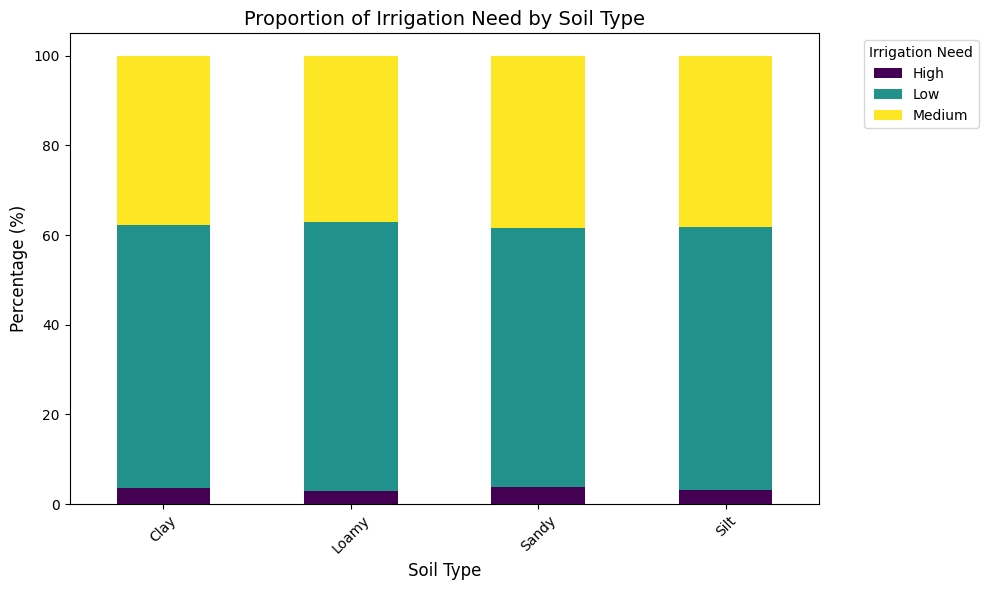

In [25]:
crosstab.plot(
    x='Soil_Type',
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='viridis'
)

plt.title('Proportion of Irrigation Need by Soil Type', fontsize=14)
plt.xlabel('Soil Type', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Irrigation Need',bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2. Which soil retains water best?

In [26]:
soil_moisture_summary = df_train.groupby('Soil_Type')['Soil_Moisture'].mean()

##Moisture increases as water retention increases

In [27]:
soil_moisture_summary = soil_moisture_summary.reset_index()

In [28]:
soil_moisture_summary

,Soil_Type,Soil_Moisture
0,Clay,37.393083
1,Loamy,37.574972
2,Sandy,36.924150
3,Silt,37.351386


In [29]:
best_retained_soil = soil_moisture_summary.loc[
    soil_moisture_summary['Soil_Moisture'].idxmax(),
    'Soil_Type'
]

best_retained_value = soil_moisture_summary['Soil_Moisture'].max()

lowest_moisture_soil = soil_moisture_summary.loc[
    soil_moisture_summary['Soil_Moisture'].idxmin(),
    'Soil_Type'
]

lowest_moisture_value = soil_moisture_summary['Soil_Moisture'].min()

print("============================ SOIL ANALYSIS ============================")
print(f"Soil that retains water best is {best_retained_soil} (Avg moisture: {best_retained_value:.2f})")
print(f"Soil that has lowest moisture is {lowest_moisture_soil} (Avg moisture: {lowest_moisture_value:.2f})")

============================ SOIL ANALYSIS ============================
Soil that retains water best is Loamy (Avg moisture: 37.57)
Soil that has lowest moisture is Sandy (Avg moisture: 36.92)


/tmp/ipykernel_959/2673408603.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


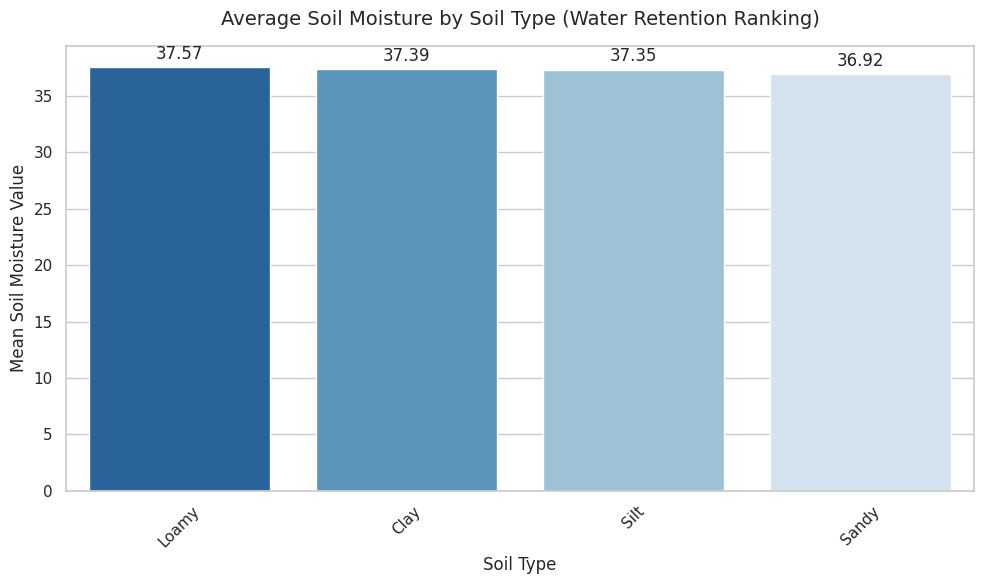

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the size and style of the plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 2. Calculate the order dynamically so the highest retention is first, lowest is last
sorted_order = df_train.groupby('Soil_Type')['Soil_Moisture'].mean().sort_values(ascending=False).index

# 3. Create a barplot of the means
# errorbar=None removes the confidence interval lines to keep the focus purely on the average
ax = sns.barplot(
    data=df_train,
    x='Soil_Type',
    y='Soil_Moisture',
    order=sorted_order,
    palette='Blues_r', # 'Blues_r' goes from dark blue (wettest) to light blue (driest)
    errorbar=None
)

# 4. Add data labels on top of each bar automatically
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

# 5. Add titles and labels
plt.title('Average Soil Moisture by Soil Type (Water Retention Ranking)', fontsize=14, pad=15)
plt.xlabel('Soil Type', fontsize=12)
plt.ylabel('Mean Soil Moisture Value', fontsize=12)
plt.xticks(rotation=45)

# 6. Show the graph cleanly
plt.tight_layout()
plt.show()

Which crops consume most water?

In [31]:
df_train.sample(1)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
263287,263287,Loamy,5.53,9.89,0.33,1.14,38.04,62.23,2316.63,8.04,17.45,Sugarcane,Flowering,Kharif,Canal,River,13.24,No,5.56,Central,High


In [32]:
crop_moisture_summary = df_train.groupby('Crop_Type')['Soil_Moisture'].mean().reset_index()

In [33]:
crop_moisture_summary

,Crop_Type,Soil_Moisture
0,Cotton,37.203140
1,Maize,37.174308
2,Potato,37.077804
3,Rice,37.293577
4,Sugarcane,37.594429
5,Wheat,37.469438


In [34]:
crop_irrigation_summary = df_train.groupby('Crop_Type')['Previous_Irrigation_mm'].mean().reset_index()

In [35]:
crop_irrigation_summary

,Crop_Type,Previous_Irrigation_mm
0,Cotton,61.148548
1,Maize,62.008484
2,Potato,61.841020
3,Rice,62.211372
4,Sugarcane,64.304585
5,Wheat,62.304963


In [36]:
thirsty_dry_soil_crop = crop_moisture_summary.loc[crop_moisture_summary['Soil_Moisture'].idxmin(), 'Crop_Type']
lowest_moisture_value = crop_moisture_summary['Soil_Moisture'].min()

most_watered_crop = crop_irrigation_summary.loc[crop_irrigation_summary['Previous_Irrigation_mm'].idxmax(), 'Crop_Type']
highest_irrigation_value = crop_irrigation_summary['Previous_Irrigation_mm'].max()

In [37]:
print("============================ CROP WATER CONSUMPTION ============================")
print(f"Crop the leaves soil the DRIEST is {thirsty_dry_soil_crop} (AVG Moisture Left: {lowest_moisture_value:.2f})")
print(f"Crop required the highest irrigation value is {most_watered_crop} (AVG Water applied: {highest_irrigation_value:.2f})")

============================ CROP WATER CONSUMPTION ============================
Crop the leaves soil the DRIEST is Potato (AVG Moisture Left: 37.08)
Crop required the highest irrigation value is Sugarcane (AVG Water applied: 64.30)


/tmp/ipykernel_959/462799276.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
/tmp/ipykernel_959/462799276.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


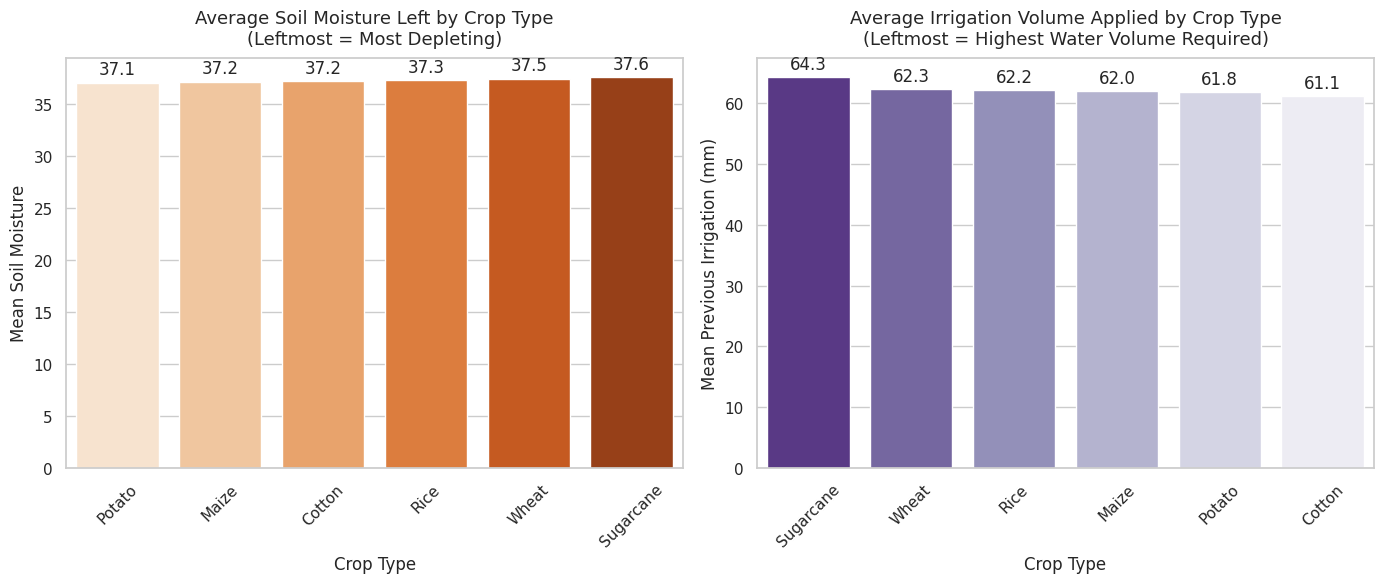

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="whitegrid")

order_moisture = crop_moisture_summary.sort_values(by='Soil_Moisture', ascending=True)['Crop_Type']

ax1 = sns.barplot(
    data=crop_moisture_summary,
    x='Crop_Type',
    y='Soil_Moisture',
    order=order_moisture,
    palette='Oranges',
    ax=axes[0]
)

for container in ax1.containers:
  ax1.bar_label(container, fmt='%1.1f', padding=3)

axes[0].set_title('Average Soil Moisture Left by Crop Type\n(Leftmost = Most Depleting)', fontsize=13, pad=10)
axes[0].set_xlabel('Crop Type')
axes[0].set_ylabel('Mean Soil Moisture')
axes[0].tick_params(axis='x', rotation=45)

order_irrigation = crop_irrigation_summary.sort_values(by='Previous_Irrigation_mm', ascending=False)['Crop_Type']

ax2 = sns.barplot(
    data=crop_irrigation_summary,
    x='Crop_Type',
    y='Previous_Irrigation_mm',
    order=order_irrigation,
    palette='Purples_r',
    ax=axes[1]
)

for container in ax2.containers:
  ax2.bar_label(container, fmt='%1.1f', padding=3)

axes[1].set_title('Average Irrigation Volume Applied by Crop Type\n(Leftmost = Highest Water Volume Required)', fontsize=13, pad=10)
axes[1].set_xlabel('Crop Type')
axes[1].set_ylabel('Mean Previous Irrigation (mm)')
axes[1].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

Sugarcane is the most water-intensive crop, receiving the highest average irrigation volume, followed by wheat and rice. Potato, maize, and cotton exhibit lower remaining soil moisture, suggesting higher irrigation dependency. Among soil types, loamy soil shows the best water retention capability, while sandy soil retains the least moisture and may require more frequent irrigation.

In [39]:
df_train.sample(1)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
155584,155584,Loamy,6.48,10.44,0.4,2.55,41.49,62.24,641.05,8.47,18.59,Cotton,Vegetative,Rabi,Rainfed,Rainwater,1.73,No,23.02,South,High


Which growth stage needs maximum water?

In [40]:
growth_stage_summary = df_train.groupby('Crop_Growth_Stage')['Previous_Irrigation_mm'].mean().reset_index()

In [41]:
growth_stage_summary

,Crop_Growth_Stage,Previous_Irrigation_mm
0,Flowering,61.940872
1,Harvest,63.090687
2,Sowing,62.009781
3,Vegetative,62.161716


In [42]:
stage_need_max_water = growth_stage_summary.loc[growth_stage_summary['Previous_Irrigation_mm'].idxmax(), 'Crop_Growth_Stage']
max_water_value = growth_stage_summary['Previous_Irrigation_mm'].max()

In [43]:
print("========================================== Growth Stage summary comp.=====================================================")
print(f"Growth stage need maximum water is {stage_need_max_water} (AVG Water Need: {max_water_value})")

========================================== Growth Stage summary comp.=====================================================
Growth stage need maximum water is Harvest (AVG Water Need: 63.09068655069802)


/tmp/ipykernel_959/541846945.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


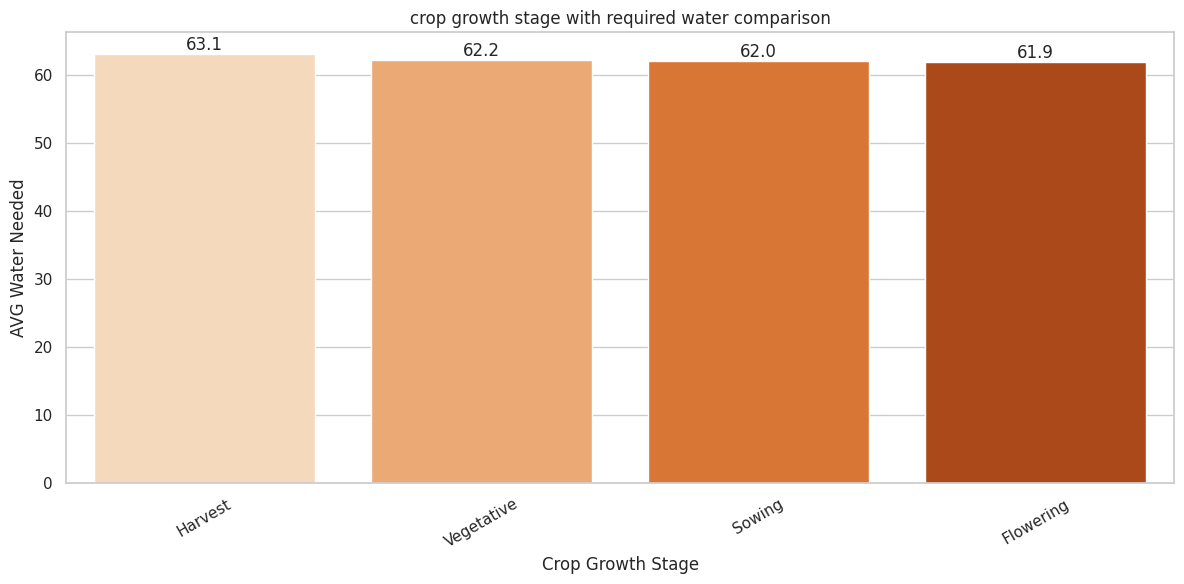

In [44]:
order = growth_stage_summary.sort_values(by='Previous_Irrigation_mm', ascending=False)['Crop_Growth_Stage']
plt.figure(figsize=(12,6))
ax1 = sns.barplot(
    data=growth_stage_summary,
    x='Crop_Growth_Stage',
    y='Previous_Irrigation_mm',
    order=order,
    palette='Oranges'
)
for container in ax1.containers:
  ax1.bar_label(container, fmt='%1.1f')

plt.title("crop growth stage with required water comparison")
plt.xlabel("Crop Growth Stage")
plt.ylabel("AVG Water Needed")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Seedling vs flowering vs harvesting comparison?

In [45]:
df_train['Season'].unique()

array(['Zaid', 'Kharif', 'Rabi'], dtype=object)

In [46]:
df_train.sample(1)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
350381,350381,Loamy,7.72,25.91,0.97,2.57,31.55,58.63,1341.94,5.71,2.89,Sugarcane,Sowing,Rabi,Rainfed,Rainwater,11.27,Yes,113.74,Central,Low


In [47]:
filtered = df_train[df_train['Irrigation_Need'] == 'High']

In [48]:
season_irrigation_summary = filtered.groupby('Season')['Irrigation_Need'].count().reset_index()

In [49]:
season_irrigation_summary

,Season,Irrigation_Need
0,Kharif,7542
1,Rabi,6681
2,Zaid,6786


In [50]:
season_demand = season_irrigation_summary.loc[season_irrigation_summary['Irrigation_Need'].idxmax(), 'Season']

In [51]:
print(f"Season which has highest irrigation demand is -> {season_demand}")

Season which has highest irrigation demand is -> Kharif


Q. Does rainfall vary by season?


In [52]:
rainfall_season_summary = df_train.groupby('Season')['Rainfall_mm'].mean().reset_index()

In [53]:
rainfall_season_summary.round(2)

,Season,Rainfall_mm
0,Kharif,1456.10
1,Rabi,1470.79
2,Zaid,1459.96


/tmp/ipykernel_959/1193488838.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


([0, 1, 2], [Text(0, 0, 'Rabi'), Text(1, 0, 'Zaid'), Text(2, 0, 'Kharif')])

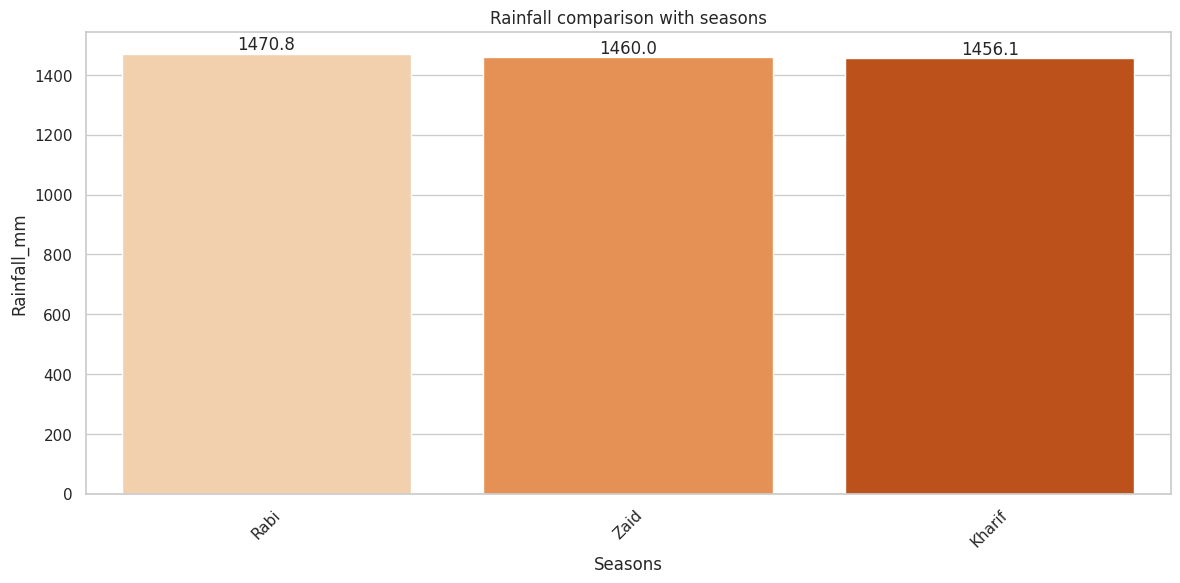

In [54]:
plt.figure(figsize=(14, 6))
order = rainfall_season_summary.sort_values(by='Rainfall_mm', ascending=False)['Season']
ax1 = sns.barplot(
    data=rainfall_season_summary,
    x='Season',
    y='Rainfall_mm',
    palette='Oranges',
    order=order
)

for container in ax1.containers:
  ax1.bar_label(container, fmt='%1.1f')

plt.title("Rainfall comparison with seasons")
plt.xlabel("Seasons")
plt.xticks(rotation=45)

- Which irrigation method is most efficient?
- Which method uses less previous irrigation water?

In [55]:
df_train.sample(1)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
190388,190388,Loamy,6.4,33.88,1.47,1.75,29.13,26.89,2052.74,8.34,14.18,Wheat,Flowering,Zaid,Canal,Reservoir,1.56,No,53.51,East,Medium


In [56]:
df_train['Irrigation_Type'].unique()

array(['Drip', 'Rainfed', 'Sprinkler', 'Canal'], dtype=object)

In [57]:
method_water_summary = df_train.groupby('Irrigation_Type')['Previous_Irrigation_mm'].mean().reset_index()

In [58]:
method_water_summary

,Irrigation_Type,Previous_Irrigation_mm
0,Canal,63.229695
1,Drip,62.173029
2,Rainfed,61.849114
3,Sprinkler,61.991937


In [59]:
lowest_water_method = method_water_summary.loc[method_water_summary['Previous_Irrigation_mm'].idxmin(), 'Irrigation_Type']
lowest_value = method_water_summary['Previous_Irrigation_mm'].min()

In [60]:
method_moisture_summary = df_train.groupby('Irrigation_Type')['Soil_Moisture'].mean().reset_index()

In [61]:
method_moisture_summary

,Irrigation_Type,Soil_Moisture
0,Canal,36.508997
1,Drip,37.705301
2,Rainfed,37.765893
3,Sprinkler,37.282365


In [62]:
max_moisture_type = method_moisture_summary.loc[method_moisture_summary['Soil_Moisture'].idxmax(), 'Irrigation_Type']
max_moisture_value = method_moisture_summary.max()

In [63]:
print("======================== IRRIGATION EFFICIENCY ANALYSIS ========================")
print(f"Method using the LEAST water volume:  {lowest_water_method} ({lowest_value:.2f} mm avg)")
print("================================================================================\n")

======================== IRRIGATION EFFICIENCY ANALYSIS ========================
Method using the LEAST water volume:  Rainfed (61.85 mm avg)



/tmp/ipykernel_959/2457563999.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
/tmp/ipykernel_959/2457563999.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


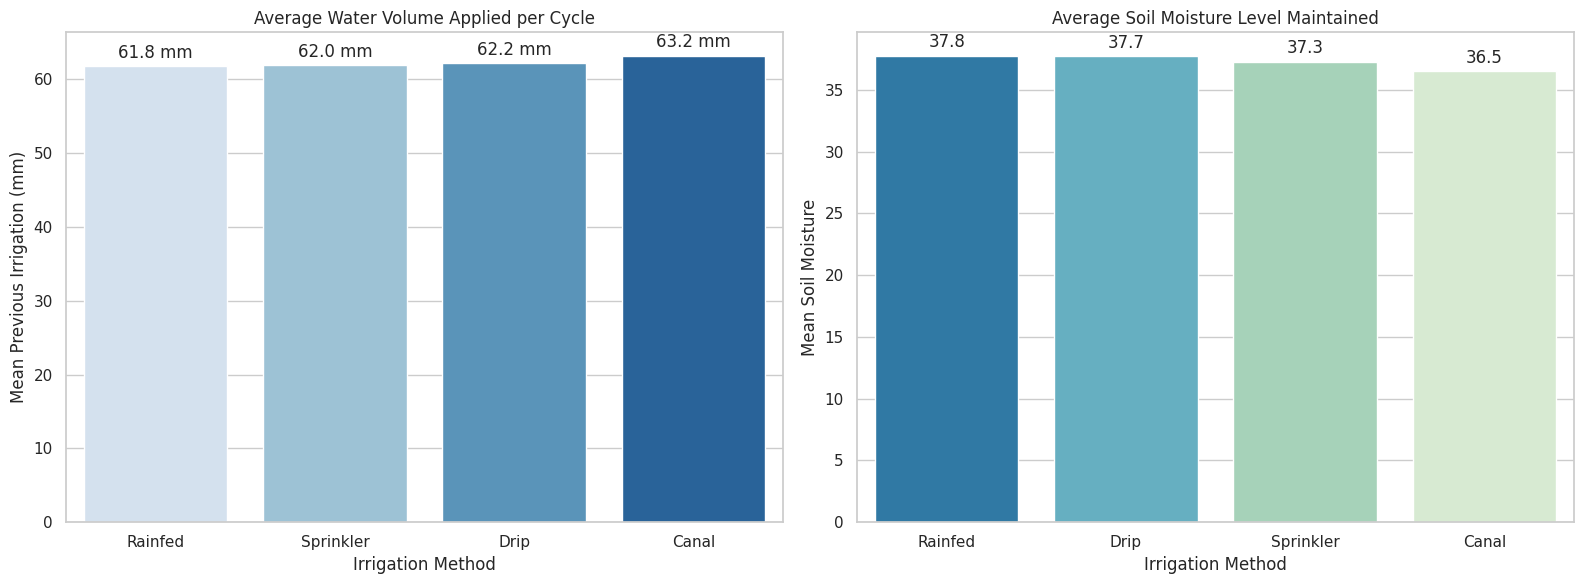

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Graph 1: Water applied by each irrigation type
vol_order = df_train.groupby('Irrigation_Type')['Previous_Irrigation_mm'].mean().sort_values().index
ax1 = sns.barplot(
    data=df_train,
    x='Irrigation_Type',
    y='Previous_Irrigation_mm',
    order=vol_order,
    palette='Blues',
    errorbar=None,
    ax=axes[0]
)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f mm', padding=3)
axes[0].set_title('Average Water Volume Applied per Cycle')
axes[0].set_xlabel('Irrigation Method')
axes[0].set_ylabel('Mean Previous Irrigation (mm)')

# Graph 2: Soil moisture profile by irrigation type
moist_order = df_train.groupby('Irrigation_Type')['Soil_Moisture'].mean().sort_values(ascending=False).index
ax2 = sns.barplot(
    data=df_train,
    x='Irrigation_Type',
    y='Soil_Moisture',
    order=moist_order,
    palette='GnBu_r',
    errorbar=None,
    ax=axes[1]
)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', padding=3)
axes[1].set_title('Average Soil Moisture Level Maintained')
axes[1].set_xlabel('Irrigation Method')
axes[1].set_ylabel('Mean Soil Moisture')

plt.tight_layout()
plt.show()

In [65]:
# Most efficient irrigation method...
efficient_method = max_moisture_type, lowest_water_method
# Both gets the same result...
print(f"Most efficient method is {max_moisture_type}")

Most efficient method is Rainfed


In [66]:
df_train.sample(1)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
31796,31796,Sandy,7.66,33.98,1.35,2.68,31.83,57.54,2355.99,5.85,0.74,Rice,Sowing,Rabi,Rainfed,River,5.61,Yes,78.09,East,Low


### Water Source
- Which regions rely on which water sources?
- Any shortage patterns?

In [67]:
water_region = pd.crosstab(
    df_train['Region'],
    df_train['Water_Source'],
    normalize='index'
) * 100

water_region = water_region.reset_index()
water_region

Water_Source,Region,Groundwater,Rainwater,Reservoir,River
0,Central,24.350912,24.195713,26.152677,25.300698
1,East,24.549987,24.447738,25.647773,25.354502
2,North,24.354447,24.354447,25.872055,25.419051
3,South,24.512458,24.250606,25.950048,25.286887
4,West,24.557699,24.215445,25.743012,25.483844


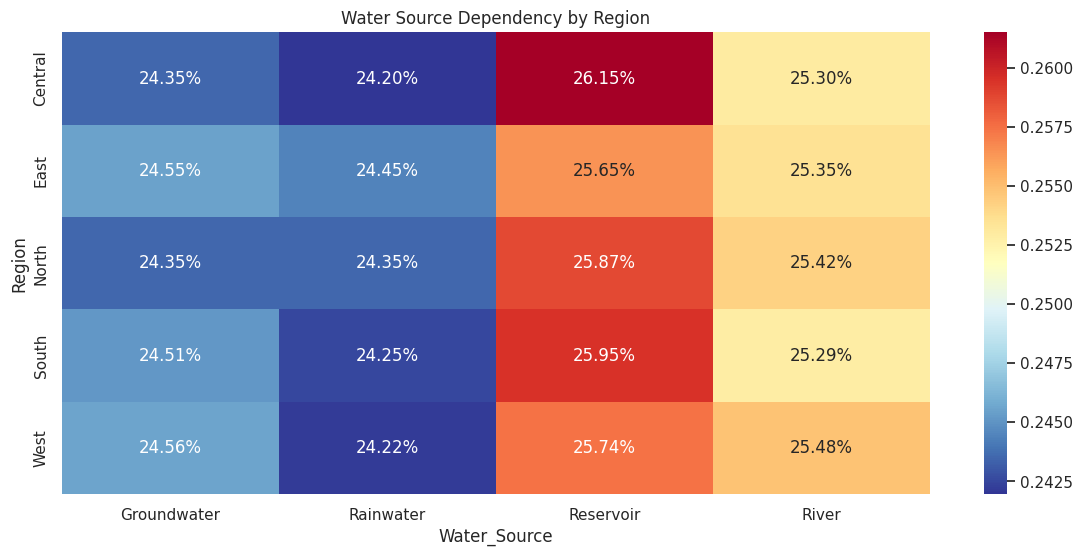

In [68]:
water_region_pct = pd.crosstab(
    df_train['Region'],
    df_train['Water_Source'],
    normalize='index'
)

plt.figure(figsize=(14,6))
sns.heatmap(
    water_region_pct,
    annot=True,
    fmt='.2%',
    cmap='RdYlBu_r'
)

plt.title('Water Source Dependency by Region')
plt.show()

### Mulching Used
Questions:

- Does mulching reduce irrigation need?
- Does mulching increase soil moisture retention?

In [69]:
df_train.sample(1)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
536149,536149,Clay,5.9,24.98,0.89,1.81,28.7,88.92,612.61,10.61,15.88,Potato,Harvest,Zaid,Canal,Groundwater,9.46,No,112.04,North,Medium


In [70]:
df_train['Mulching_Used'].unique()

array(['No', 'Yes'], dtype=object)

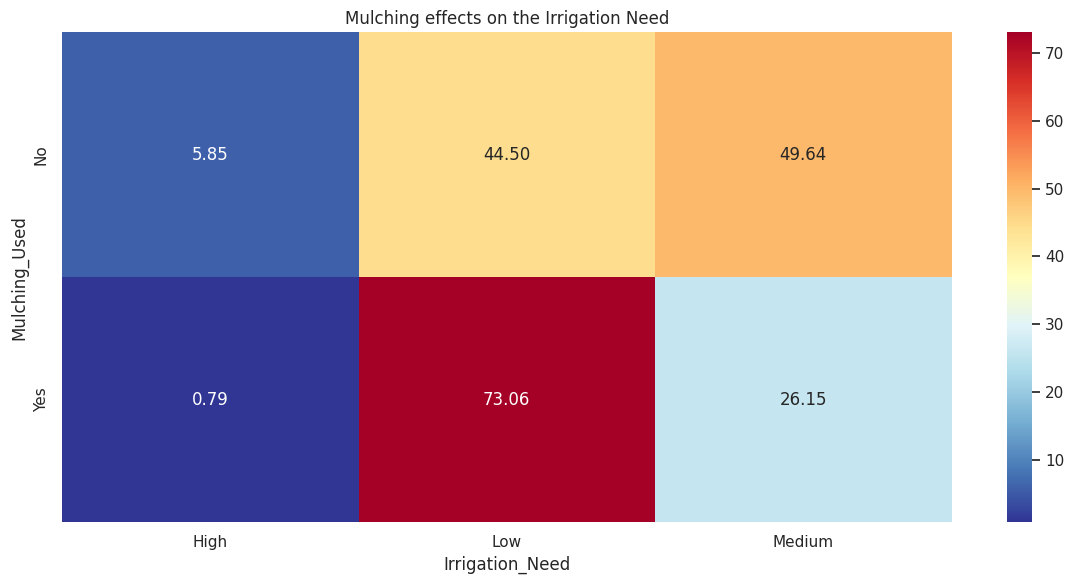

In [71]:
mulching_influence = pd.crosstab(
    df_train['Mulching_Used'],
    df_train['Irrigation_Need'],
    normalize='index'
) * 100

plt.figure(figsize=(12, 6))
sns.heatmap(
    mulching_influence,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r'
)

plt.title("Mulching effects on the Irrigation Need")
plt.tight_layout()
plt.show()

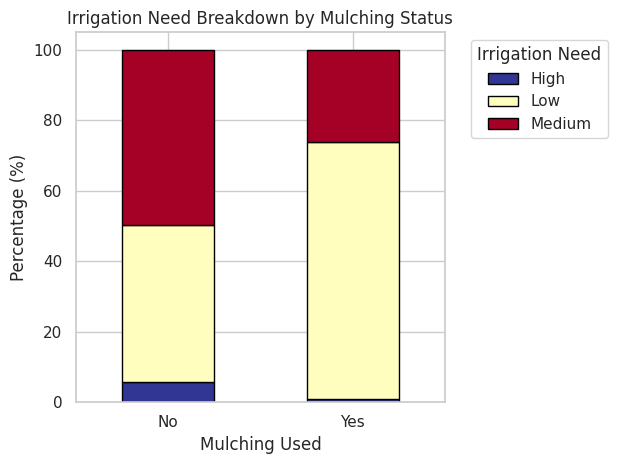

In [72]:
# Since it's already normalized by index, plotting it directly makes a 100% stacked chart
mulching_influence.plot(kind='bar', stacked=True, colormap='RdYlBu_r', edgecolor='black')

plt.title('Irrigation Need Breakdown by Mulching Status')
plt.ylabel('Percentage (%)')
plt.xlabel('Mulching Used')
plt.xticks(rotation=0) # Keeps 'Yes' and 'No' horizontal and easy to read
plt.legend(title='Irrigation Need', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

- Yes mulching reduced irrigation need as we can see high demard reduced from 5.85 to 0.79.

/tmp/ipykernel_959/1222575121.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


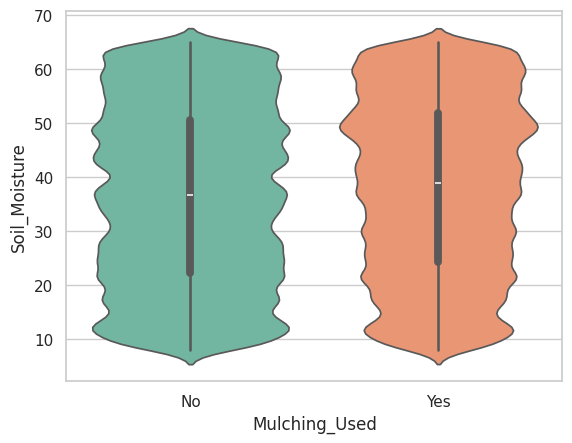

In [73]:
sns.violinplot(
    data=df_train,
    x='Mulching_Used',
    y='Soil_Moisture',
    palette='Set2'
)
plt.show()

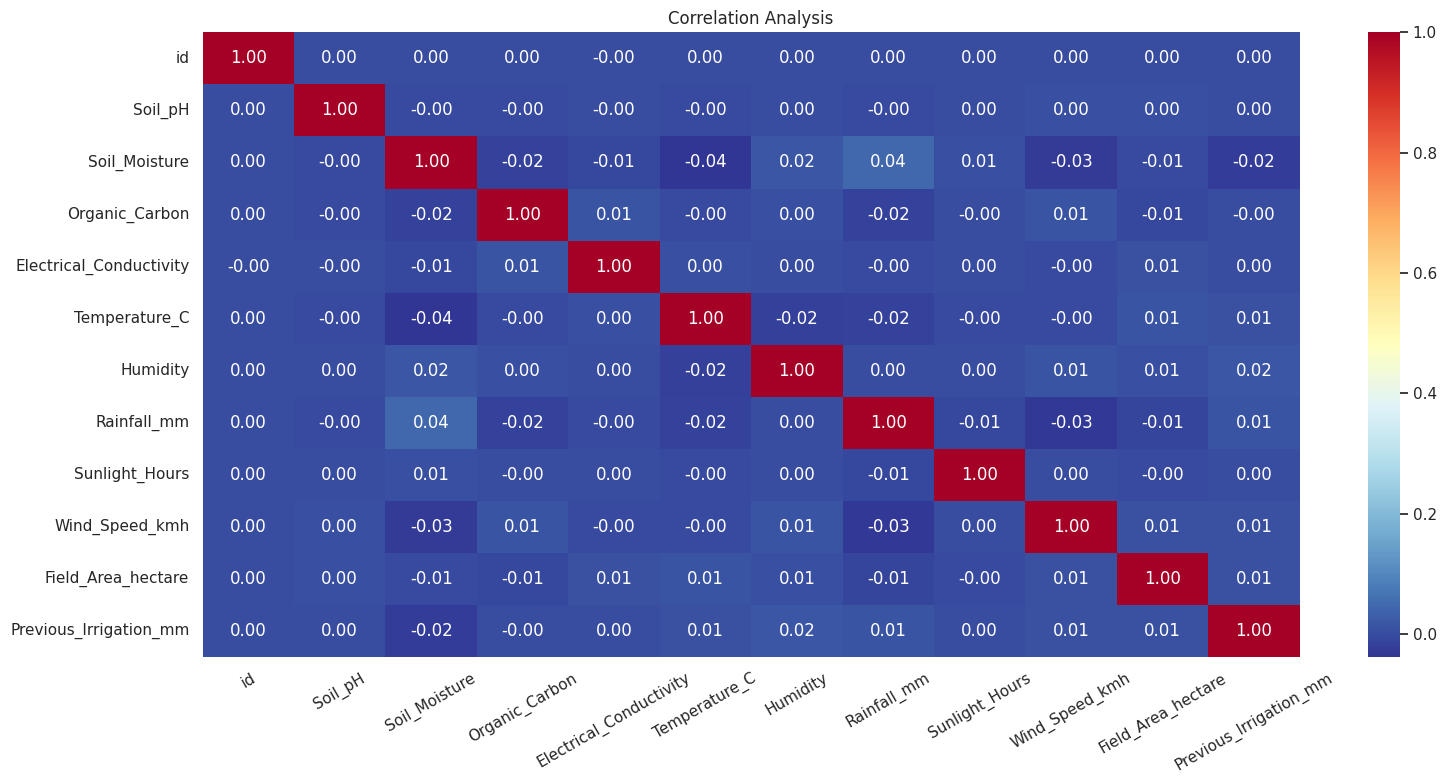

In [74]:
corr = df_train.corr(numeric_only=True)

plt.figure(figsize=(16, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r'
)
plt.title("Correlation Analysis")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

/tmp/ipykernel_959/2748582997.py:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


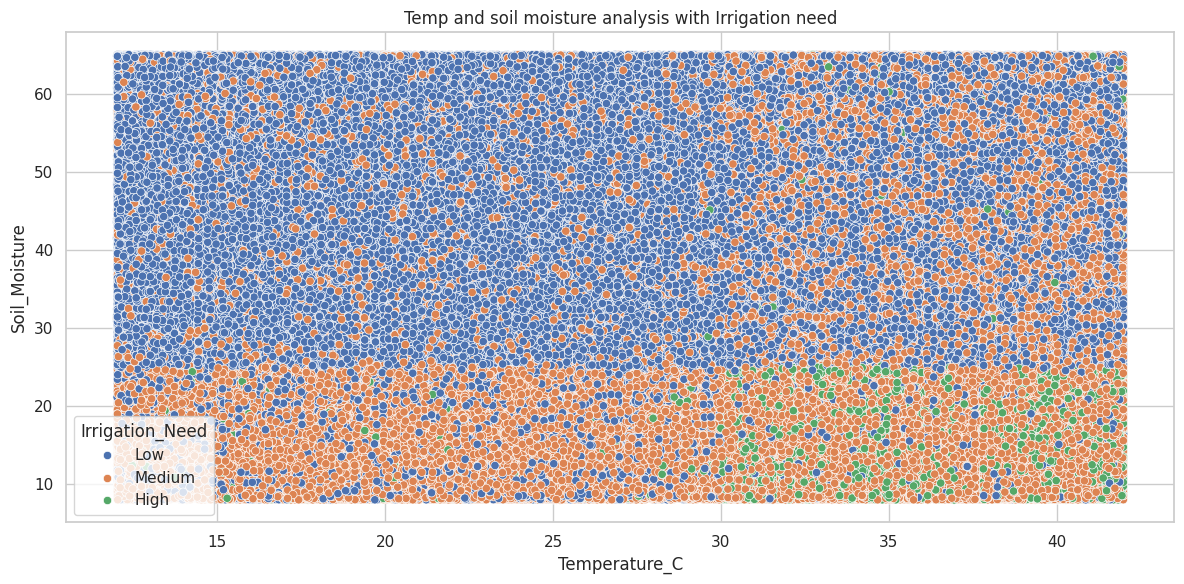

In [75]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x="Temperature_C",
    y="Soil_Moisture",
    hue="Irrigation_Need",
    data=df_train
)
plt.title("Temp and soil moisture analysis with Irrigation need")
plt.tight_layout()
plt.show()

$$\text{Irrigation Need} =
\begin{cases} \text{Low} & \text{if } \text{Soil Moisture} > 25 \\
\text{Medium} & \text{if } \text{Soil Moisture} \le 25 \text{ AND } \text{Temperature} < 28^\circ\text{C} \\
\text{High/Medium Mix} & \text{if } \text{Soil Moisture} \le 25 \text{ AND } \text{Temperature} \ge 28^\circ\text{C}
\end{cases}$$

In [76]:
df_train.sample(1)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
284202,284202,Loamy,5.6,26.71,0.61,0.26,38.46,28.57,633.6,7.75,12.86,Sugarcane,Sowing,Kharif,Rainfed,River,3.25,Yes,94.61,East,Low


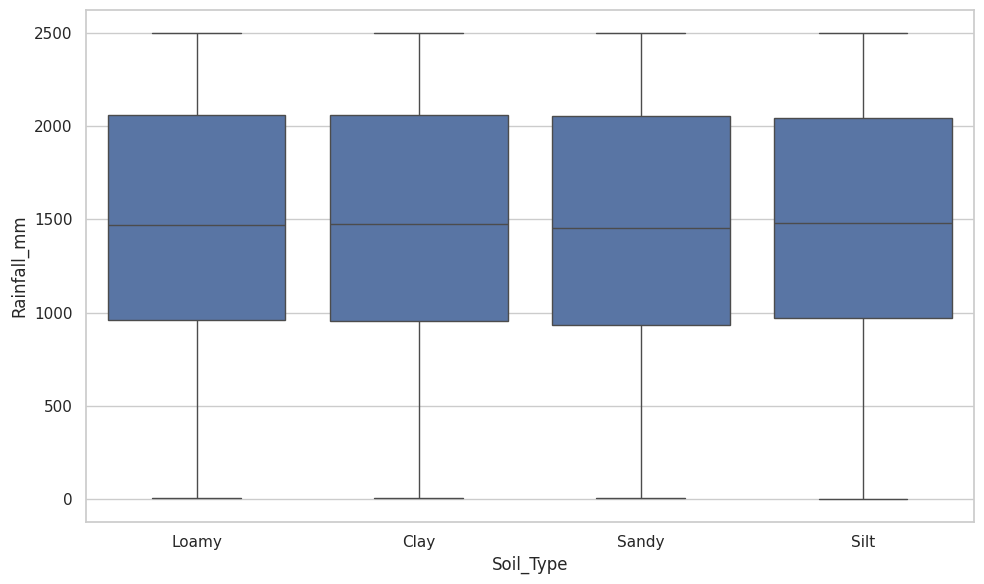

In [77]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_train,
    x='Soil_Type',
    y='Rainfall_mm',
    orient='v',
)

plt.tight_layout()
plt.show()

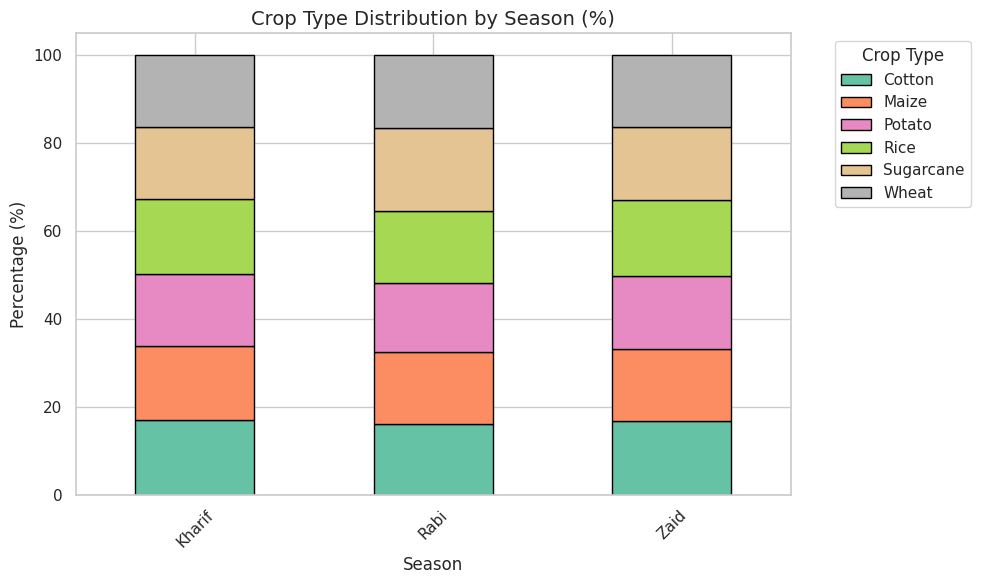

In [78]:
# Save your crosstab to a variable
season_crop = pd.crosstab(
    df_train['Season'],
    df_train['Crop_Type'],
    normalize='index'
) * 100

# Plot as a stacked bar chart
season_crop.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2', edgecolor='black')

plt.title('Crop Type Distribution by Season (%)', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xlabel('Season')
plt.xticks(rotation=45)
plt.legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Feature Engineering...

In [79]:
BASELINE_MOISTURE = 25

# Moisture Deficit
df_train['Moisture_Deficit'] = (
    BASELINE_MOISTURE - df_train['Soil_Moisture']
)

$$\text{Moisture Deficit} = \text{Baseline Moisture} - \text{Soil Moisture}$$

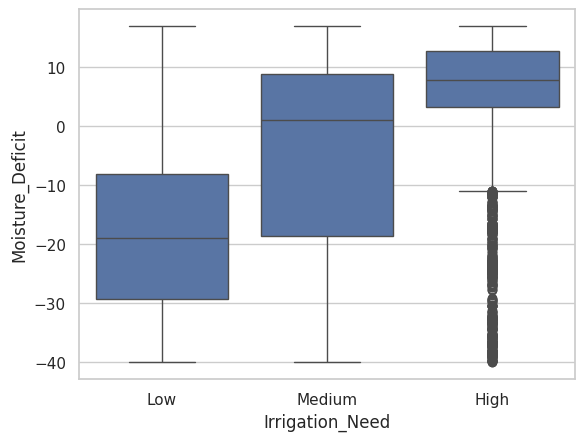

In [80]:
sns.boxplot(
    data=df_train,
    x="Irrigation_Need",
    y="Moisture_Deficit"
)

plt.show()

In [81]:
df_train.groupby("Irrigation_Need")["Moisture_Deficit"].describe()

,count,mean,std,min,25%,50%,75%,max
Irrigation_Need,,,,,,,,
High,21009.0,7.330125,7.479613,-39.99,3.33,7.91,12.86,16.99
Low,369917.0,-18.305902,13.421279,-39.99,-29.31,-19.01,-8.03,16.99
Medium,239074.0,-4.743961,16.624592,-39.99,-18.66,1.11,8.97,17.00


In [82]:
from scipy.stats import f_oneway

low = df_train[df_train["Irrigation_Need"]=="Low"]["Moisture_Deficit"]
med = df_train[df_train["Irrigation_Need"]=="Medium"]["Moisture_Deficit"]
high = df_train[df_train["Irrigation_Need"]=="High"]["Moisture_Deficit"]

f_stat, p_value = f_oneway(low, med, high)

print(f_stat)
print(p_value)

82555.91785943085
0.0


$$\text{ET Proxy} = \frac{\text{Temperature} \times \text{Sunlight Hours} \times \text{Wind Speed}}{\text{Humidity} + 1}$$

In [83]:
# Evapotranspiration Proxy
df_train['ET_Proxy'] = (
    df_train['Temperature_C'] * df_train['Sunlight_Hours'] * df_train['Wind_Speed_kmh']
) / (df_train['Humidity'] + 1)

<Axes: xlabel='ET_Proxy', ylabel='Soil_Moisture'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


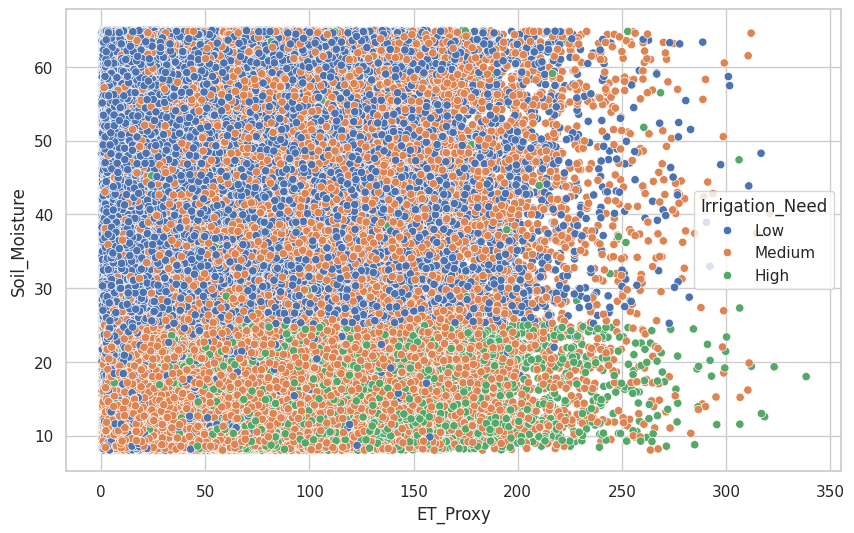

In [84]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_train,
    x="ET_Proxy",
    y="Soil_Moisture",
    hue="Irrigation_Need"
)

Water Stress Index = (ET_Proxy) / (Soil Moisture+1)

In [85]:
df_train["Water_Stress_Index"] = (
    df_train["ET_Proxy"] /
    (df_train["Soil_Moisture"] + 1)
)

<Axes: xlabel='Irrigation_Need', ylabel='Water_Stress_Index'>

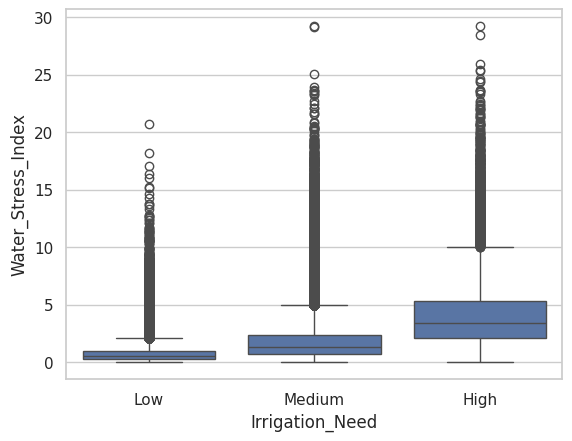

In [86]:
sns.boxplot(
    data=df_train,
    x="Irrigation_Need",
    y="Water_Stress_Index"
)

In [87]:
df_train.groupby("Irrigation_Need")["ET_Proxy"].describe()

,count,mean,std,min,25%,50%,75%,max
Irrigation_Need,,,,,,,,
High,21009.0,68.974061,42.320796,0.848618,40.479772,59.279257,87.676699,338.409139
Low,369917.0,31.076561,28.409943,0.331428,11.228063,23.006047,41.709215,316.758248
Medium,239074.0,45.617785,35.149492,0.465773,20.910879,37.140073,60.655539,320.842204


In [88]:
from scipy.stats import f_oneway

low = df_train[df_train['Irrigation_Need']=='Low']['ET_Proxy']
med = df_train[df_train['Irrigation_Need']=='Medium']['ET_Proxy']
high = df_train[df_train['Irrigation_Need']=='High']['ET_Proxy']

f_stat, p_value = f_oneway(low, med, high)

print(f_stat)
print(p_value)

25809.95120092286
0.0


In [89]:
df_train.groupby("Irrigation_Need")["Water_Stress_Index"].describe()

,count,mean,std,min,25%,50%,75%,max
Irrigation_Need,,,,,,,,
High,21009.0,4.166455,3.017805,0.032689,2.144060,3.391599,5.305387,29.222146
Low,369917.0,0.779677,0.804848,0.005161,0.260761,0.541297,1.015232,20.737003
Medium,239074.0,1.876781,1.818156,0.010533,0.715235,1.331548,2.405881,29.202719


In [90]:
low = df_train[df_train["Irrigation_Need"]=="Low"]["Water_Stress_Index"]
med = df_train[df_train["Irrigation_Need"]=="Medium"]["Water_Stress_Index"]
high = df_train[df_train["Irrigation_Need"]=="High"]["Water_Stress_Index"]

f,p = f_oneway(low,med,high)

print(f)
print(p)

90857.71775875475
0.0


$$\text{Rain Temp Ratio} = \frac{\text{Rainfall mm}}{\text{Temperature C} + 1}$$

In [91]:
# Rainfall Temperature Ratio
df_train['Rain_Temp_Ratio'] = (
    df_train['Rainfall_mm'] / (df_train['Temperature_C'] + 1)
)

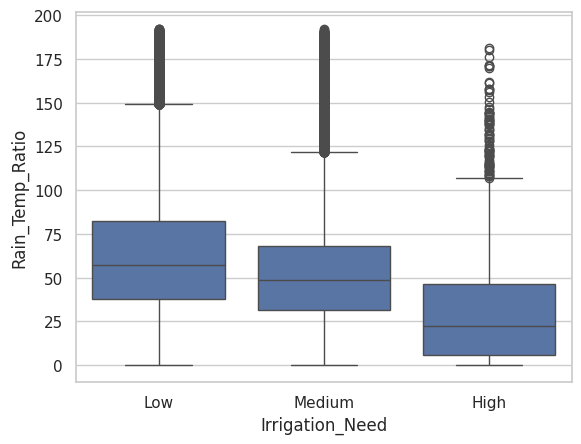

In [92]:
sns.boxplot(
    data=df_train,
    x="Irrigation_Need",
    y="Rain_Temp_Ratio"
)

plt.show()

In [93]:
df_train.groupby("Irrigation_Need")["Rain_Temp_Ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
Irrigation_Need,,,,,,,,
High,21009.0,28.096731,23.483941,0.056113,5.947847,22.205492,46.371469,181.263433
Low,369917.0,63.402130,33.730252,0.053515,37.877199,56.976260,82.413580,191.971582
Medium,239074.0,53.316347,30.303057,0.009625,31.790522,48.633111,67.847725,191.817345


In [94]:
low = df_train[df_train["Irrigation_Need"]=="Low"]["Rain_Temp_Ratio"]
med = df_train[df_train["Irrigation_Need"]=="Medium"]["Rain_Temp_Ratio"]
high = df_train[df_train["Irrigation_Need"]=="High"]["Rain_Temp_Ratio"]

f,p = f_oneway(low, med, high)

print("F-stat:", f)
print("P-value:", p)

F-stat: 16777.740259017504
P-value: 0.0


$$\text{Water Efficiency} = \frac{\text{Soil Moisture}}{\text{Previous Irrigation} + \text{Rainfall} + 1}$$

In [95]:
# Total Water Input
df_train["Total_Water_Input"] = (
    df_train["Rainfall_mm"]
    + df_train["Previous_Irrigation_mm"]
)

# Water Efficiency Score
df_train["Water_Efficiency"] = (
    df_train["Soil_Moisture"]
    / (df_train["Total_Water_Input"] + 1)
)

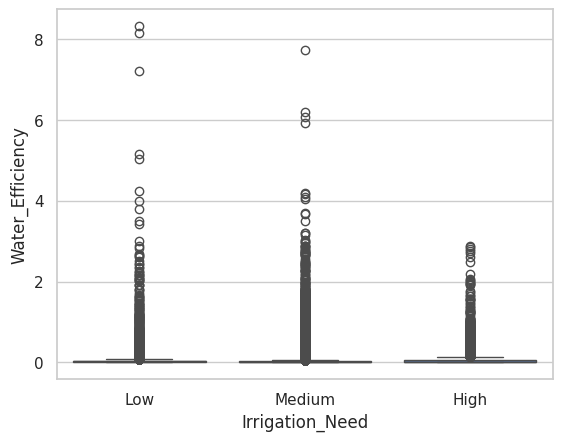

In [96]:
sns.boxplot(
    data=df_train,
    x="Irrigation_Need",
    y="Water_Efficiency"
)

plt.show()

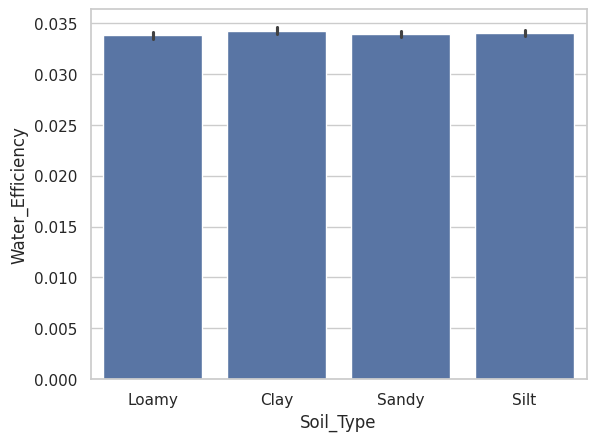

In [97]:
sns.barplot(
    data=df_train,
    x="Soil_Type",
    y="Water_Efficiency"
)

plt.show()

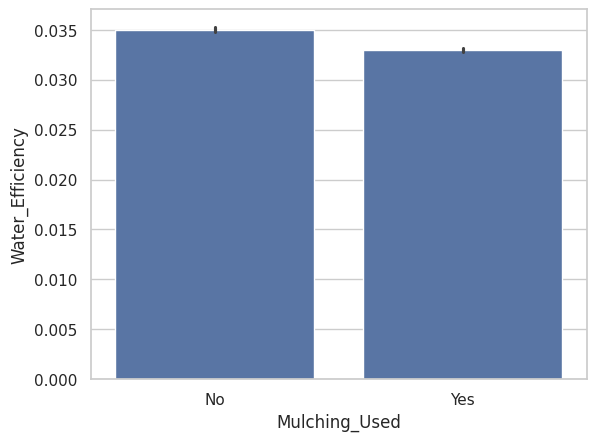

In [98]:
sns.barplot(
    data=df_train,
    x="Mulching_Used",
    y="Water_Efficiency"
)

plt.show()

In [99]:
df_train = df_train.drop(columns=['Total_Water_Input', 'Water_Efficiency'], axis=1)

In [100]:
df_train.groupby("Irrigation_Need")["Soil_Moisture"].describe()

,count,mean,std,min,25%,50%,75%,max
Irrigation_Need,,,,,,,,
High,21009.0,17.669875,7.479613,8.01,12.14,17.09,21.67,64.99
Low,369917.0,43.305902,13.421279,8.01,33.03,44.01,54.31,64.99
Medium,239074.0,29.743961,16.624592,8.00,16.03,23.89,43.66,64.99


In [101]:
target_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

df_train["Target_Encoded"] = df_train["Irrigation_Need"].map(target_map)

In [102]:
cols_to_exclude = ['Irrigation_Need', 'id', 'Target_Encoded']

numerical_features = [col for col in df_train.select_dtypes(include=['int64', 'float64']).columns if col not in cols_to_exclude]

anova_results = []

for col in numerical_features:

    low = df_train[df_train["Irrigation_Need"]=="Low"][col]
    medium = df_train[df_train["Irrigation_Need"]=="Medium"][col]
    high = df_train[df_train["Irrigation_Need"]=="High"][col]

    f_stat, p_val = f_oneway(low, medium, high)

    anova_results.append({
        "Feature": col,
        "ANOVA_F": f_stat,
        "P_Value": p_val
    })

feature_scores = pd.DataFrame(anova_results)

feature_scores = feature_scores.sort_values(
    "ANOVA_F",
    ascending=False
)

feature_scores.head(20)

,Feature,ANOVA_F,P_Value
13,Water_Stress_Index,90857.717759,0.000000e+00
1,Soil_Moisture,82555.917859,0.000000e+00
11,Moisture_Deficit,82555.917859,0.000000e+00
12,ET_Proxy,25809.951201,0.000000e+00
8,Wind_Speed_kmh,22514.094175,0.000000e+00
4,Temperature_C,22043.759085,0.000000e+00
14,Rain_Temp_Ratio,16777.740259,0.000000e+00
6,Rainfall_mm,7241.631185,0.000000e+00
5,Humidity,172.297278,1.558475e-75
0,Soil_pH,158.296161,1.862596e-69


In [103]:
df_train.head(1)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need,Moisture_Deficit,ET_Proxy,Water_Stress_Index,Rain_Temp_Ratio,Target_Encoded
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.9,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low,-7.58,28.810417,0.857964,45.346034,0


In [104]:
df_train = df_train.drop('Irrigation_Need', axis=1)

In [105]:
df_train.head(1)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Moisture_Deficit,ET_Proxy,Water_Stress_Index,Rain_Temp_Ratio,Target_Encoded
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.9,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,-7.58,28.810417,0.857964,45.346034,0


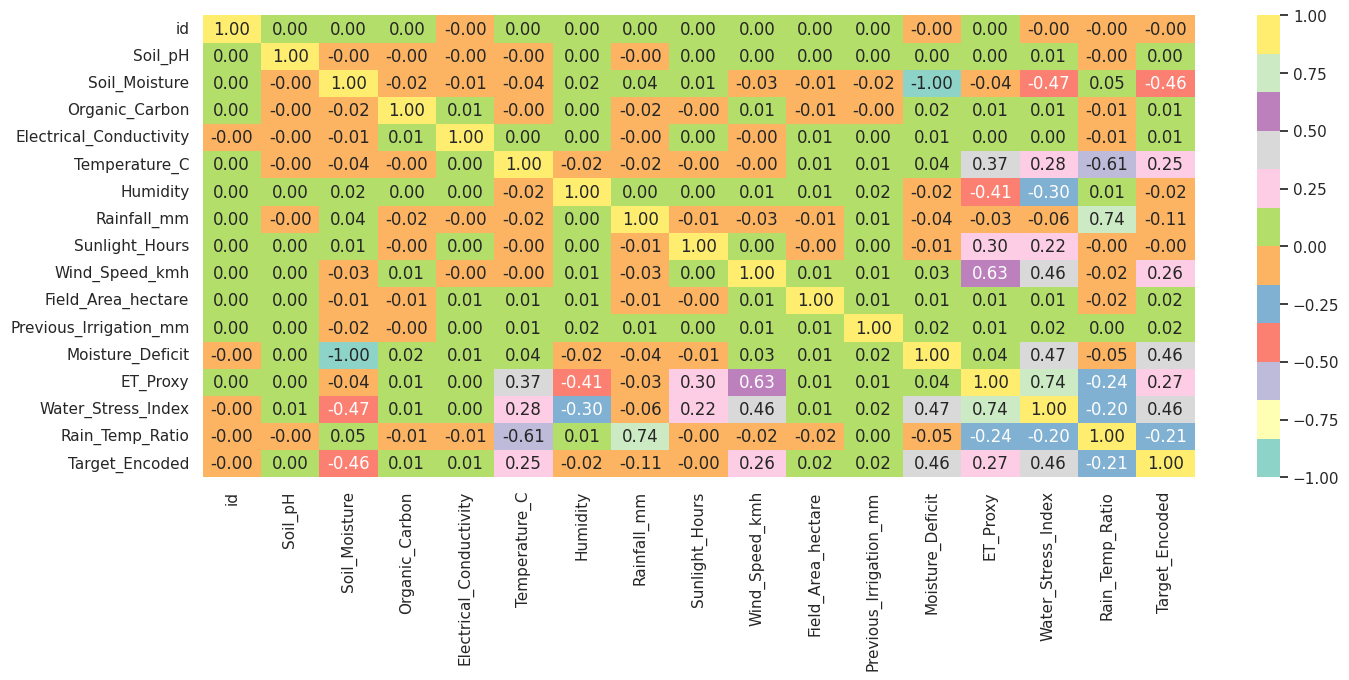

In [106]:
corr = df_train.corr(numeric_only=True)

plt.figure(figsize=(16, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='Set3'
)

plt.show()

In [107]:
df_train = df_train.drop('Moisture_Deficit', axis=1)

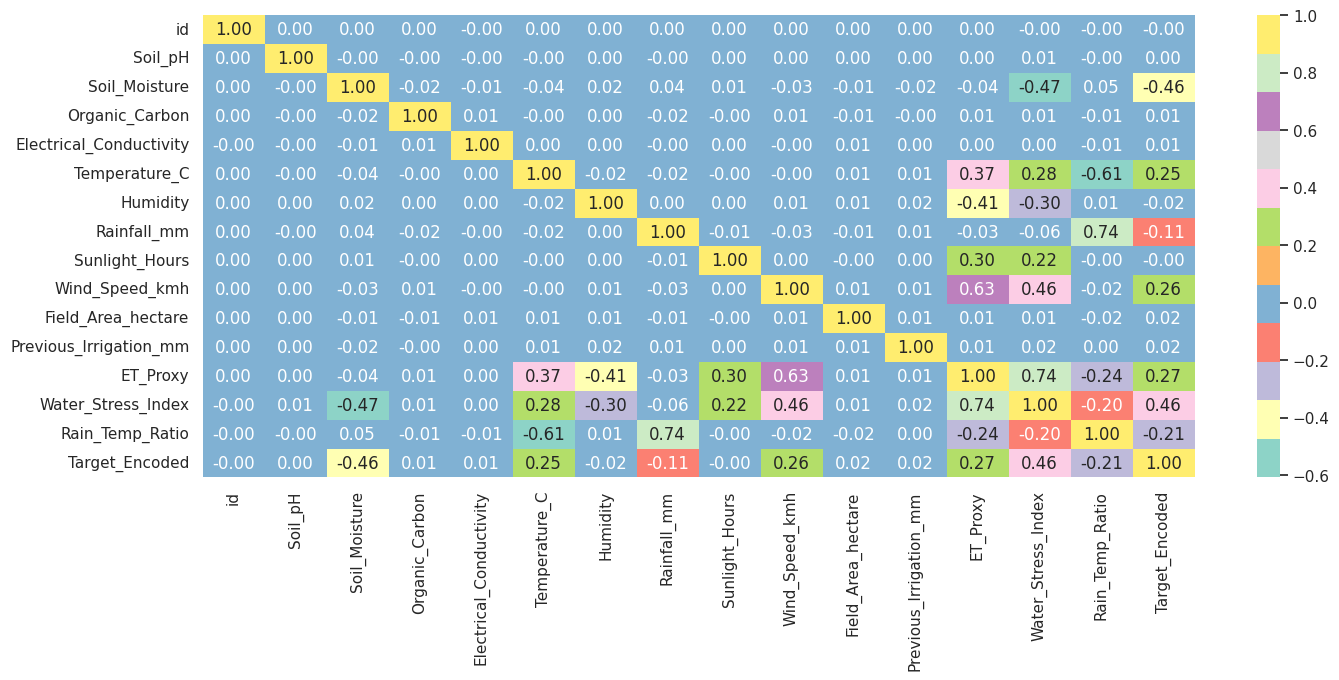

In [108]:
corr = df_train.corr(numeric_only=True)

plt.figure(figsize=(16, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='Set3'
)

plt.show()

In [109]:
capped = ['Irrigation_Need', 'Target_Encoded']
numerical_feature = [col for col in df_train.select_dtypes(include=['int64', 'float64']).columns if col not in capped]

In [110]:
from sklearn.feature_selection import mutual_info_classif

X = df_train[numerical_feature]

y = df_train["Target_Encoded"]

mi = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MI": mi
}).sort_values(
    "MI",
    ascending=False
)

print(mi_df)

                    Feature        MI
2             Soil_Moisture  0.205361
7               Rainfall_mm  0.188587
13       Water_Stress_Index  0.136835
5             Temperature_C  0.074484
9            Wind_Speed_kmh  0.063451
14          Rain_Temp_Ratio  0.057049
11   Previous_Irrigation_mm  0.053053
6                  Humidity  0.048564
12                 ET_Proxy  0.046148
4   Electrical_Conductivity  0.011785
3            Organic_Carbon  0.011570
1                   Soil_pH  0.010115
10       Field_Area_hectare  0.009806
8            Sunlight_Hours  0.007431
0                        id  0.000137


In [111]:
corr_with_target = (
    df_train.corr(numeric_only=True)["Target_Encoded"]
    .drop("Target_Encoded")
)

corr_df = corr_with_target.reset_index()

corr_df.columns = [
    "Feature",
    "Correlation"
]

corr_df.head()

,Feature,Correlation
0,id,-0.000903
1,Soil_pH,0.000150
2,Soil_Moisture,-0.455482
3,Organic_Carbon,0.006451
4,Electrical_Conductivity,0.010785


In [112]:
final_rank = (
    feature_scores[["Feature","ANOVA_F"]]
    .merge(corr_df,on="Feature")
    .merge(mi_df,on="Feature")
)

final_rank

,Feature,ANOVA_F,Correlation,MI
0,Water_Stress_Index,90857.717759,0.458675,0.136835
1,Soil_Moisture,82555.917859,-0.455482,0.205361
2,ET_Proxy,25809.951201,0.272094,0.046148
3,Wind_Speed_kmh,22514.094175,0.258170,0.063451
4,Temperature_C,22043.759085,0.252867,0.074484
5,Rain_Temp_Ratio,16777.740259,-0.213527,0.057049
6,Rainfall_mm,7241.631185,-0.111478,0.188587
7,Humidity,172.297278,-0.021870,0.048564
8,Soil_pH,158.296161,0.000150,0.010115
9,Electrical_Conductivity,146.958066,0.010785,0.011785


In [113]:
drop_features = [
    "Sunlight_Hours",
    "Field_Area_hectare",
    "Organic_Carbon"
]

In [114]:
df_model = df_train.drop(
    columns=drop_features
)

print(df_model.shape)

(630000, 21)


In [192]:
from sklearn.preprocessing import LabelEncoder

df_cat = df_model.copy()

label_encoders = {}

cat_cols = [
    "Soil_Type",
    "Crop_Type",
    "Crop_Growth_Stage",
    "Season",
    "Irrigation_Type",
    "Water_Source",
    "Region",
    "Mulching_Used"
]

for col in cat_cols:
    le = LabelEncoder()

    df_cat[col] = le.fit_transform(
        df_cat[col].astype(str)
    )

    label_encoders[col] = le

In [116]:
X_cat = df_cat[cat_cols]

y = df_cat["Target_Encoded"]

mi_cat = mutual_info_classif(
    X_cat,
    y,
    discrete_features=True,
    random_state=42
)

mi_cat_df = pd.DataFrame({
    "Feature": cat_cols,
    "MI": mi_cat
})

mi_cat_df = mi_cat_df.sort_values(
    "MI",
    ascending=False
)

print(mi_cat_df)

             Feature        MI
2  Crop_Growth_Stage  0.166707
7      Mulching_Used  0.046896
5       Water_Source  0.001309
1          Crop_Type  0.000884
4    Irrigation_Type  0.000878
0          Soil_Type  0.000321
3             Season  0.000296
6             Region  0.000153


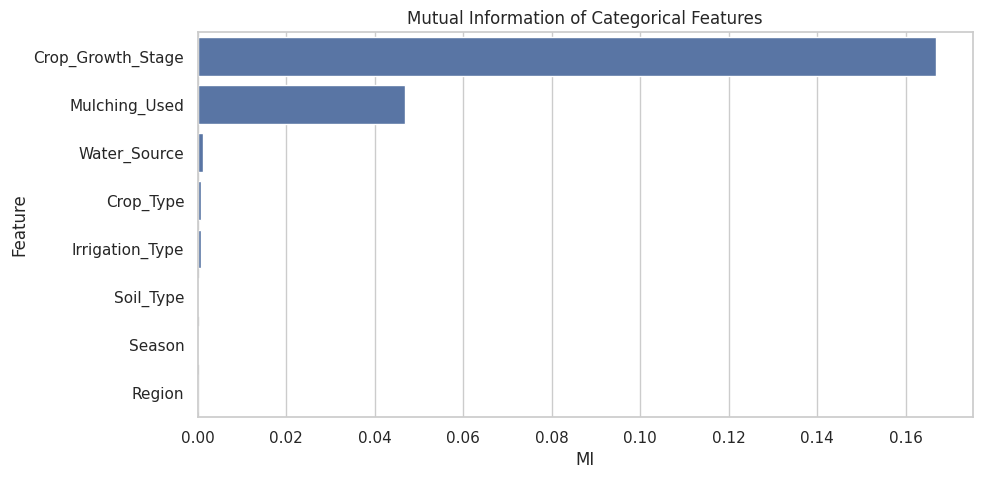

In [117]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=mi_cat_df,
    x="MI",
    y="Feature"
)

plt.title("Mutual Information of Categorical Features")
plt.show()

In [118]:
!pip install lightgbm -q

In [119]:
df_model.sample(1)

,id,Soil_Type,Soil_pH,Soil_Moisture,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Mulching_Used,Previous_Irrigation_mm,Region,ET_Proxy,Water_Stress_Index,Rain_Temp_Ratio,Target_Encoded
586170,586170,Sandy,6.84,28.48,0.2,24.63,54.96,1046.91,10.62,Maize,Harvest,Kharif,Rainfed,Reservoir,Yes,51.94,West,28.185681,0.956095,40.847054,0


In [120]:
cat_cols = [
    "Soil_Type",
    "Crop_Type",
    "Crop_Growth_Stage",
    "Season",
    "Irrigation_Type",
    "Water_Source",
    "Region",
    "Mulching_Used"
]

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

In [121]:
drop_cols_A = [
    "id",
    "Target_Encoded",
]

X_A = df_model.drop(columns=drop_cols_A)

y = df_model["Target_Encoded"]

In [122]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from lightgbm import LGBMClassifier

In [123]:
lgbm_A = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "f1_macro": "f1_macro",
    "balanced_acc": "balanced_accuracy",
    "accuracy": "accuracy"
}

scores_A = cross_validate(
    lgbm_A,
    X_A,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("MODEL A (ALL FEATURES)")
print("-"*40)

print("Accuracy:",
      scores_A["test_accuracy"].mean())

print("Balanced Accuracy:",
      scores_A["test_balanced_acc"].mean())

print("Macro F1:",
      scores_A["test_f1_macro"].mean())


MODEL A (ALL FEATURES)
----------------------------------------
Accuracy: 0.9844031746031746
Balanced Accuracy: 0.961857679025439
Macro F1: 0.9696883386616528


In [124]:
df_model.sample(1)

,id,Soil_Type,Soil_pH,Soil_Moisture,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Mulching_Used,Previous_Irrigation_mm,Region,ET_Proxy,Water_Stress_Index,Rain_Temp_Ratio,Target_Encoded
22237,22237,3,5.46,18.3,2.58,19.45,52.75,1847.48,18.49,2,3,1,1,2,1,37.77,2,39.743352,2.059241,90.34132,1


In [125]:
selected_features = [

    # Numerical
    "Soil_Moisture",
    "Water_Stress_Index",
    "Rainfall_mm",
    "Temperature_C",
    "Wind_Speed_kmh",
    "Rain_Temp_Ratio",
    "ET_Proxy",
    "Humidity",
    "Previous_Irrigation_mm",
    "Electrical_Conductivity",

    # Categorical
    "Crop_Growth_Stage",
    "Mulching_Used"
]

X_B = df_model[selected_features]

In [126]:
lgbm_B = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

scores_B = cross_validate(
    lgbm_B,
    X_B,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("MODEL B (SELECTED FEATURES)")
print("-"*40)

print("Accuracy:",
      scores_B["test_accuracy"].mean())

print("Balanced Accuracy:",
      scores_B["test_balanced_acc"].mean())

print("Macro F1:",
      scores_B["test_f1_macro"].mean())

MODEL B (SELECTED FEATURES)
----------------------------------------
Accuracy: 0.9844492063492064
Balanced Accuracy: 0.9619481182763228
Macro F1: 0.9697261604433661


In [127]:
comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1"
    ],

    "Model_A_All_Features": [
        scores_A["test_accuracy"].mean(),
        scores_A["test_balanced_acc"].mean(),
        scores_A["test_f1_macro"].mean()
    ],

    "Model_B_Selected_Features": [
        scores_B["test_accuracy"].mean(),
        scores_B["test_balanced_acc"].mean(),
        scores_B["test_f1_macro"].mean()
    ]

})

comparison

,Metric,Model_A_All_Features,Model_B_Selected_Features
0,Accuracy,0.984403,0.984449
1,Balanced Accuracy,0.961858,0.961948
2,Macro F1,0.969688,0.969726


In [129]:
from sklearn.model_selection import train_test_split

X = df_model[selected_features]

y = df_model["Target_Encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [178]:
lgbm_model = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    verbose=-1,
)

In [179]:
lgbm_model.fit(X_train, y_train)

y_pred = lgbm_model.predict(X_test)

y_prob = lgbm_model.predict_proba(X_test)

In [169]:
from sklearn.metrics import accuracy_score,balanced_accuracy_score, f1_score

acc_score = accuracy_score(y_test, y_pred)
print(f"Accuracy score: {acc_score}")

bal_acc_score = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced accuracy score: {bal_acc_score}")

f1_score_val = f1_score(
    y_test,
    y_pred,
    average='macro'
)

print(f"F1 Score: {f1_score_val}")

Accuracy score: 0.9826746031746032
Balanced accuracy score: 0.9679987969681282
F1 Score: 0.9591002658585243


In [170]:
from sklearn.metrics import classification_report, confusion_matrix

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     73983
           1       0.99      0.97      0.98     47815
           2       0.88      0.94      0.91      4202

    accuracy                           0.98    126000
   macro avg       0.95      0.97      0.96    126000
weighted avg       0.98      0.98      0.98    126000



In [171]:
cm = confusion_matrix(
    y_test,
    y_pred
)

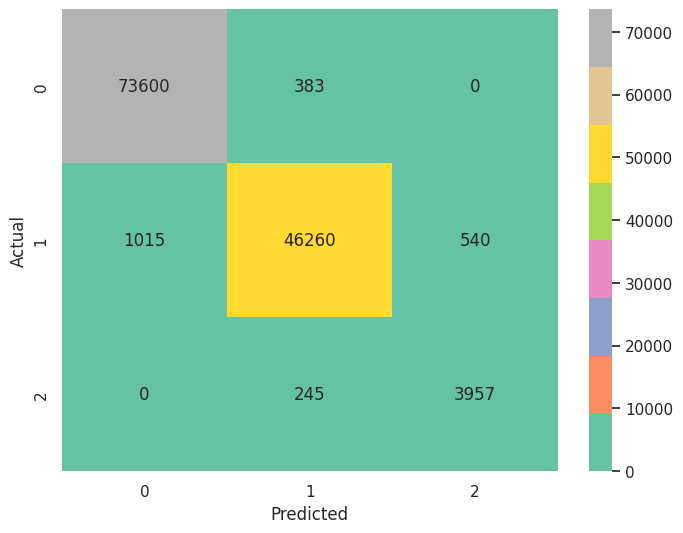

In [172]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Set2'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [173]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class='ovr'
)

print(roc_auc)

0.9970917273237275


Overall OVR ROC-AUC Score: 0.9971


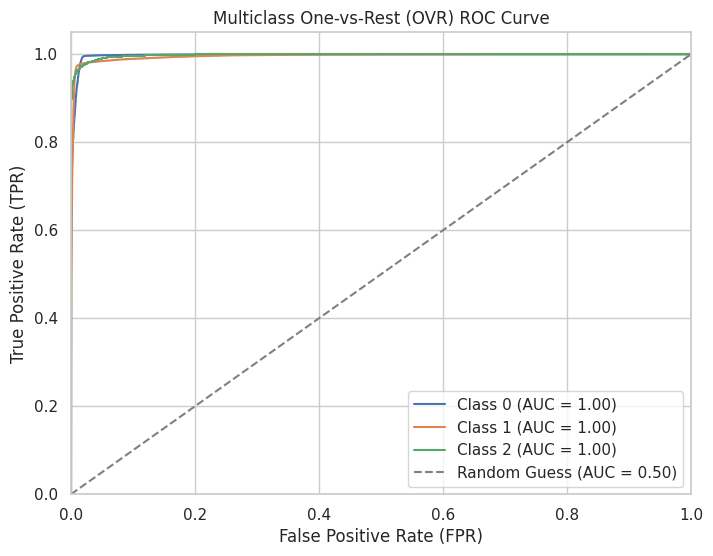

In [174]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# 1. Calculate the overall OVR ROC-AUC score (Your original code)
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
print(f"Overall OVR ROC-AUC Score: {roc_auc:.4f}")

# 2. Binarize y_test labels for multiclass plotting
label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)
n_classes = y_test_binarized.shape[1]

# 3. Plotting the ROC curves
plt.figure(figsize=(8, 6))

# Loop through each class to calculate and plot its specific ROC curve
for i in range(n_classes):
    # y_prob must be a 2D array of probabilities for all classes
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    class_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {label_binarizer.classes_[i]} (AUC = {class_auc:.2f})')

# Plot the diagonal reference line for a random classifier
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (AUC = 0.50)')

# Graph formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Multiclass One-vs-Rest (OVR) ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)

# Display the graph
plt.show()

In [175]:
from sklearn.metrics import precision_score, recall_score

precision_value = precision_score(
    y_test,
    y_pred,
    average='macro'
)

recall_value = recall_score(
    y_test,
    y_pred,
    average='macro'
)

print(f"Preccision score: {precision_value}")
print(f"Recall score: {recall_value}")

Preccision score: 0.95097438829727
Recall score: 0.9679987969681282


In [143]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance_df.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
2,Rainfall_mm,3625
3,Temperature_C,3290
0,Soil_Moisture,3246
4,Wind_Speed_kmh,2773
8,Previous_Irrigation_mm,2477
10,Crop_Growth_Stage,2257
7,Humidity,2207
5,Rain_Temp_Ratio,1921
11,Mulching_Used,1569
9,Electrical_Conductivity,1550


<Axes: xlabel='Importance', ylabel='Feature'>

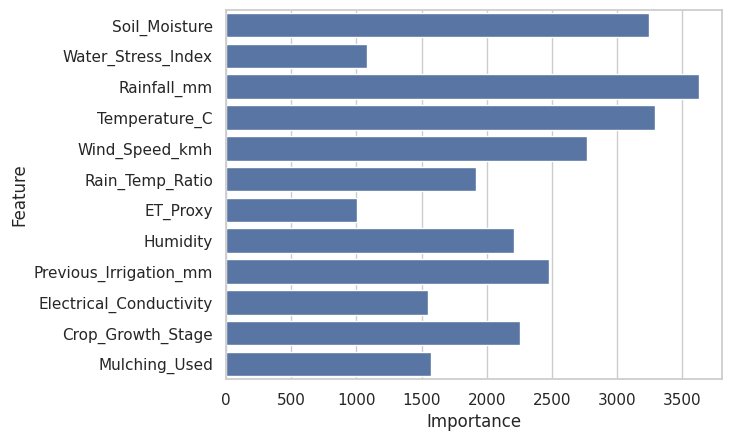

In [144]:
sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

In [149]:
import xgboost as xgb
model_xgb = xgb.XGBClassifier(
    objective='multi:softprob',  # Multiclass objective returning probabilities
    num_class=3,                 # Number of classes
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss'       # Evaluation metric for multiclass
)

In [150]:
model_xgb.fit(X_train, y_train)

# Predict classes and probabilities
y_pred_xgb = model_xgb.predict(X_test)
y_prob_xgb = model_xgb.predict_proba(X_test)

In [151]:
# --- Evaluation Metrics ---
print("--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

acc_score_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy score: {acc_score_xgb:.4f}")

bal_acc_score_xgb = balanced_accuracy_score(y_test, y_pred_xgb)
print(f"Balanced accuracy score: {bal_acc_score_xgb:.4f}")

f1_score_val_xgb = f1_score(y_test, y_pred_xgb, average='macro')
print(f"F1 Score: {f1_score_val_xgb:.4f}")

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     73983
           1       0.98      0.98      0.98     47815
           2       0.96      0.91      0.94      4202

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000

Accuracy score: 0.9847
Balanced accuracy score: 0.9602
F1 Score: 0.9689


In [153]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [154]:
from catboost import CatBoostClassifier
# Define the CatBoost model
model_cat = CatBoostClassifier(
    loss_function='MultiClass',  # Multiclass objective
    classes_count=3,             # Number of classes
    iterations=300,              # Equivalent to n_estimators
    learning_rate=0.05,
    random_state=42,
    verbose=0                    # Stops it from printing training logs for every tree
)

In [155]:
model_cat.fit(X_train, y_train)

# Predict classes and probabilities
y_pred_cat = model_cat.predict(X_test)
y_prob_cat = model_cat.predict_proba(X_test)

# Note: CatBoost sometimes returns y_pred as a 2D array [[0], [1]].
# We flatten it to a 1D array to avoid warnings in sklearn metrics.
y_pred_cat = y_pred_cat.ravel()

In [156]:
# --- Evaluation Metrics ---
print("--- CatBoost Classification Report ---")
print(classification_report(y_test, y_pred_cat))

acc_score_cat = accuracy_score(y_test, y_pred_cat)
print(f"Accuracy score: {acc_score_cat:.4f}")

bal_acc_score_cat = balanced_accuracy_score(y_test, y_pred_cat)
print(f"Balanced accuracy score: {bal_acc_score_cat:.4f}")

f1_score_val_cat = f1_score(y_test, y_pred_cat, average='macro')
print(f"F1 Score: {f1_score_val_cat:.4f}")

--- CatBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     73983
           1       0.98      0.98      0.98     47815
           2       0.96      0.91      0.93      4202

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000

Accuracy score: 0.9842
Balanced accuracy score: 0.9588
F1 Score: 0.9679


In [160]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1  # Uses all available CPU cores to speed up training
)

In [161]:
model_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [162]:
y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)

# --- Standard Evaluation Metrics ---
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

acc_score_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy score: {acc_score_rf:.4f}")

bal_acc_score_rf = balanced_accuracy_score(y_test, y_pred_rf)
print(f"Balanced accuracy score: {bal_acc_score_rf:.4f}")

f1_score_val_rf = f1_score(y_test, y_pred_rf, average='macro')
print(f"F1 Score (Macro): {f1_score_val_rf:.4f}")

# --- ROC-AUC Score and Plotting ---
roc_auc_rf = roc_auc_score(y_test, y_prob_rf, multi_class='ovr')
print(f"Overall OVR ROC-AUC Score: {roc_auc_rf:.4f}")

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     73983
           1       0.99      0.98      0.98     47815
           2       0.97      0.91      0.94      4202

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000

Accuracy score: 0.9854
Balanced accuracy score: 0.9595
F1 Score (Macro): 0.9696
Overall OVR ROC-AUC Score: 0.9957


In [181]:
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import LabelBinarizer

ensemble_model = VotingClassifier(
    estimators=[
        ('lgbm', lgbm_model),
        ('xgb', model_xgb),
        ('cat_boost', model_cat)
    ],
    voting='soft'
)

ensemble_model.fit(X_train, y_train)

y_pred = ensemble_model.predict(X_test)
y_prob = ensemble_model.predict_proba(X_test)

In [194]:
# --- Standard Evaluation Metrics ---
print("--- Voting Ensemble Classification Report ---")
print(classification_report(y_test, y_pred))

acc_score = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

print(f"Accuracy score: {acc_score:.4f}")
print(f"Balanced accuracy score: {balanced_accuracy:.4f}")
print(f"F1 Score (Macro): {macro_f1:.4f}")

# --- ROC-AUC Score and Plotting ---
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
print(f"Overall OVR ROC-AUC Score: {roc_auc:.4f}")

--- Voting Ensemble Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     73983
           1       0.98      0.98      0.98     47815
           2       0.96      0.91      0.94      4202

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000

Accuracy score: 0.9848
Balanced accuracy score: 0.9602
F1 Score (Macro): 0.9690
Overall OVR ROC-AUC Score: 0.9974


In [183]:
import joblib

joblib.dump(
    ensemble_model,
    "irrigation_ensemble_model.pkl"
)

['irrigation_ensemble_model.pkl']

In [193]:
joblib.dump(
    label_encoders,
    "label_encoders.pkl"
)

['label_encoders.pkl']

In [186]:
reverse_map = {
    0:"Low",
    1:"Medium",
    2:"High"
}

joblib.dump(
    reverse_map,
    "target_mapping.pkl"
)

['target_mapping.pkl']

In [187]:
selected_features = [
    "Soil_Moisture",
    "Water_Stress_Index",
    "Rainfall_mm",
    "Temperature_C",
    "Wind_Speed_kmh",
    "Rain_Temp_Ratio",
    "ET_Proxy",
    "Humidity",
    "Previous_Irrigation_mm",
    "Electrical_Conductivity",
    "Crop_Growth_Stage",
    "Mulching_Used"
]

In [188]:
joblib.dump(
    selected_features,
    "selected_features.pkl"
)

['selected_features.pkl']

In [189]:
def create_features(df):

    df["ET_Proxy"] = (
        df["Temperature_C"]
        * df["Sunlight_Hours"]
        * df["Wind_Speed_kmh"]
    ) / (df["Humidity"] + 1)

    df["Water_Stress_Index"] = (
        df["ET_Proxy"]
        / (df["Soil_Moisture"] + 1)
    )

    df["Rain_Temp_Ratio"] = (
        df["Rainfall_mm"]
        / (df["Temperature_C"] + 1)
    )

    return df

In [195]:
model_metrics = {
    "Accuracy": acc_score,
    "Macro_F1": macro_f1,
    "Balanced_Accuracy": balanced_accuracy,
    "ROC_AUC": roc_auc
}

joblib.dump(
    model_metrics,
    "metrics.pkl"
)

['metrics.pkl']

In [197]:
artifacts = {
    "model": ensemble_model,

    "encoders": label_encoders,

    "selected_features": selected_features,

    "target_map": {
        0: "Low",
        1: "Medium",
        2: "High"
    }
}

joblib.dump(
    artifacts,
    "/content/drive/MyDrive/ML/Predicting Irrigation Need/saved/irrigation_app.pkl"
)

['/content/drive/MyDrive/ML/Predicting Irrigation Need/saved/irrigation_app.pkl']